In [92]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'crop-recommendation-dataset' dataset.
Path to dataset files: /kaggle/input/crop-recommendation-dataset


In [93]:
from google.colab import files

uploaded = files.upload()



Saving Crop_recommendation.csv to Crop_recommendation (1).csv


In [94]:

import pandas as pd

df = pd.read_csv("Crop_recommendation.csv")
df.head(100)



,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
95,88,46,42,22.683191,83.463583,6.604993,194.265172,rice
96,93,47,37,21.533463,82.140041,6.500343,295.924880,rice
97,60,55,45,21.408658,83.329319,5.935745,287.576694,rice
98,78,35,44,26.543481,84.673536,7.072656,183.622266,rice


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [96]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [97]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [98]:
df["label"].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


In [99]:
df["label"].nunique()

22

/tmp/ipykernel_3762/1868022035.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


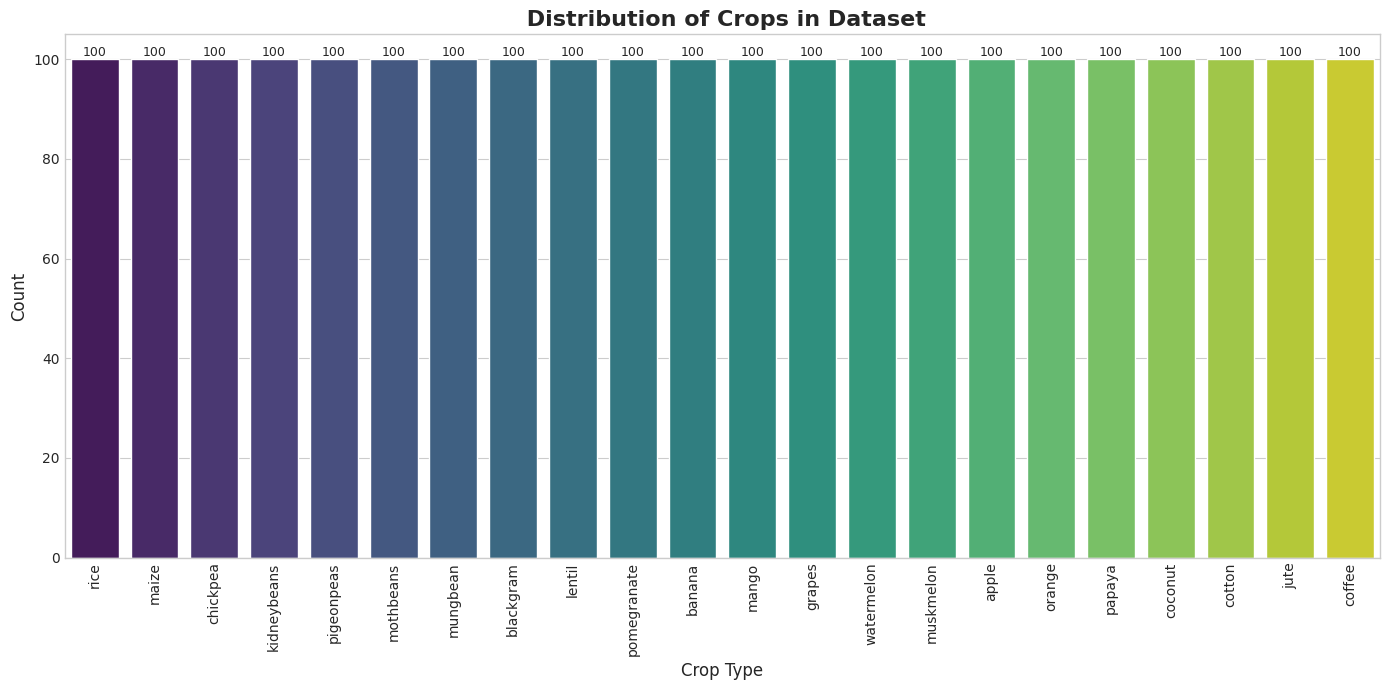

In [100]:
# EDA - Crop Distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

# style
sns.set_style("whitegrid")

# color palette
palette = sns.color_palette("viridis", len(df["label"].unique()))

# plot
ax = sns.countplot(
    x=df["label"],
    order=df["label"].value_counts().index,
    palette=palette
)

# title
plt.title(" Distribution of Crops in Dataset", fontsize=16, fontweight='bold')

# labels
plt.xlabel("Crop Type", fontsize=12)
plt.ylabel("Count", fontsize=12)

# rotate x labels
plt.xticks(rotation=90)

# add values on top of bars
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), '.0f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

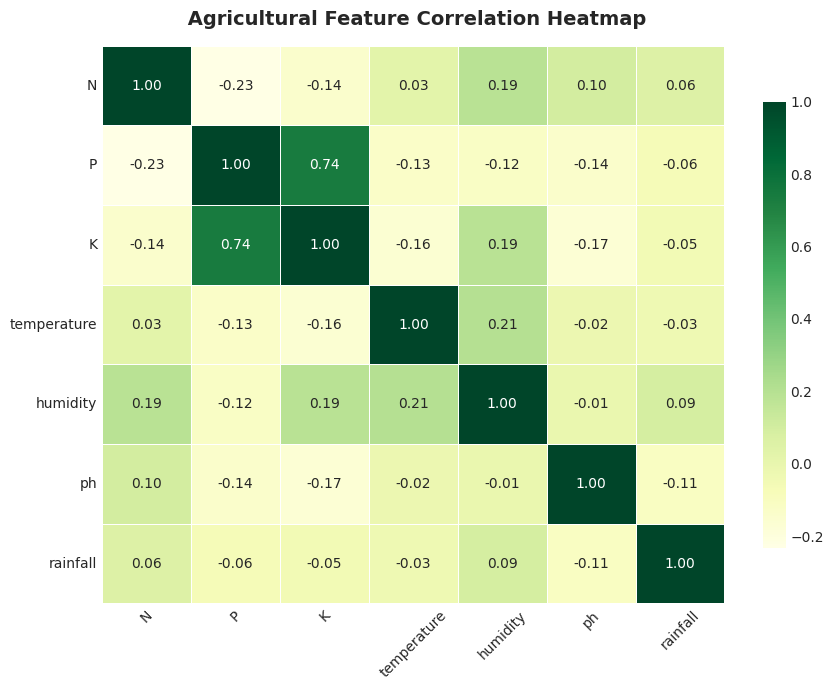

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,7))

sns.set_style("white")

cmap = sns.color_palette("YlGn", as_cmap=True)

sns.heatmap(
    df.drop("label", axis=1).corr(),
    annot=True,
    fmt=".2f",
    cmap=cmap,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8}
)

plt.title(" Agricultural Feature Correlation Heatmap",
          fontsize=14, fontweight='bold', pad=15)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

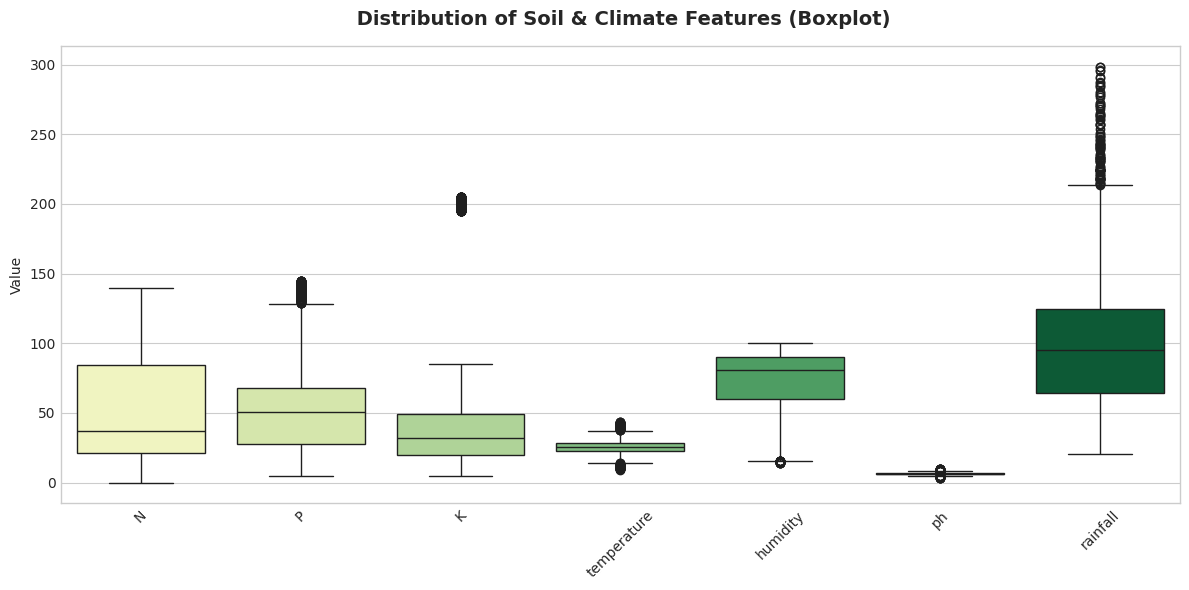

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.set_style("whitegrid")

palette = sns.color_palette("YlGn", n_colors=df.drop("label", axis=1).shape[1])

sns.boxplot(
    data=df.drop("label", axis=1),
    palette=palette
)

plt.title(" Distribution of Soil & Climate Features (Boxplot)",
          fontsize=14, fontweight='bold', pad=15)

plt.xticks(rotation=45)
plt.ylabel("Value")

plt.tight_layout()
plt.show()

In [103]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["label_encoded"] = le.fit_transform(df["label"])

df[["label","label_encoded"]].head(10)

,label,label_encoded
0,rice,20
1,rice,20
2,rice,20
3,rice,20
4,rice,20
5,rice,20
6,rice,20
7,rice,20
8,rice,20
9,rice,20


In [104]:
X = df.drop(["label","label_encoded"], axis=1)

y = df["label_encoded"]


In [105]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [106]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)



(1760, 7)
(440, 7)
(1760,)
(440,)


In [107]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)



In [108]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy_lr)


Accuracy: 0.9727272727272728


In [109]:
print(classification_report(y_test, y_pred_lr))






              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        20
           4       0.95      1.00      0.98        20
           5       1.00      1.00      1.00        20
           6       0.95      1.00      0.98        20
           7       1.00      1.00      1.00        20
           8       0.83      1.00      0.91        20
           9       1.00      1.00      1.00        20
          10       0.94      0.85      0.89        20
          11       1.00      0.95      0.97        20
          12       0.95      1.00      0.98        20
          13       0.90      0.90      0.90        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      0.95      0.97        20
          17       1.00    

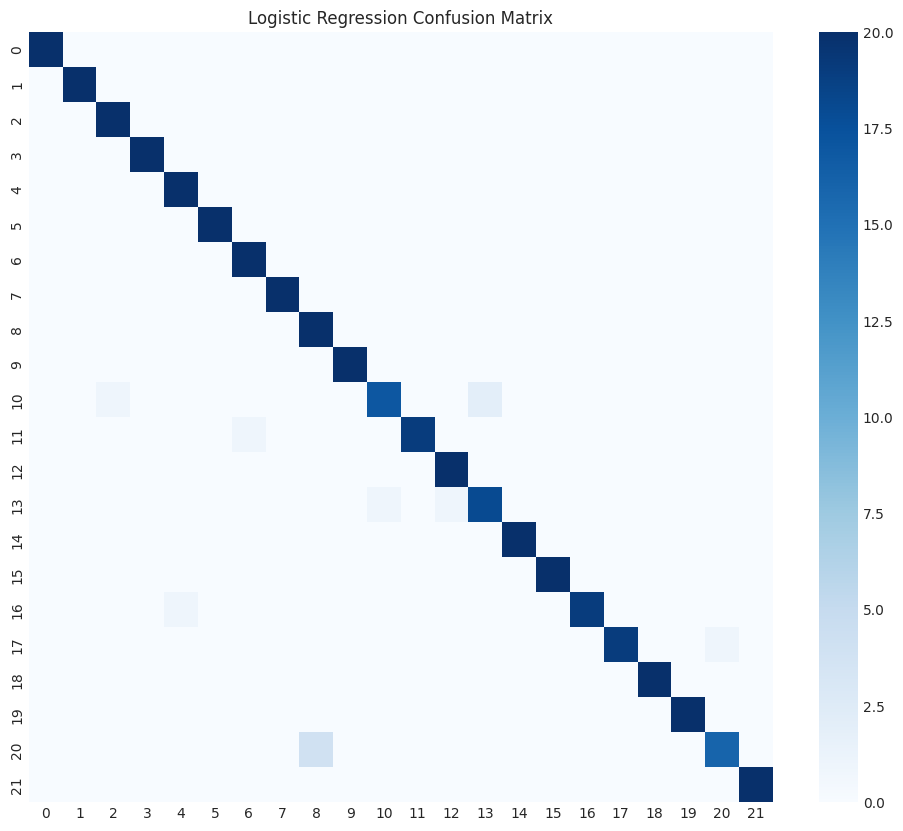

In [110]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [111]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Accuracy:", accuracy_dt)



Accuracy: 0.9795454545454545


In [112]:
print(classification_report(y_test, y_pred_dt))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.80      0.89        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      0.95      0.95        20
           9       1.00      1.00      1.00        20
          10       0.86      0.90      0.88        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       0.86      0.95      0.90        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00    

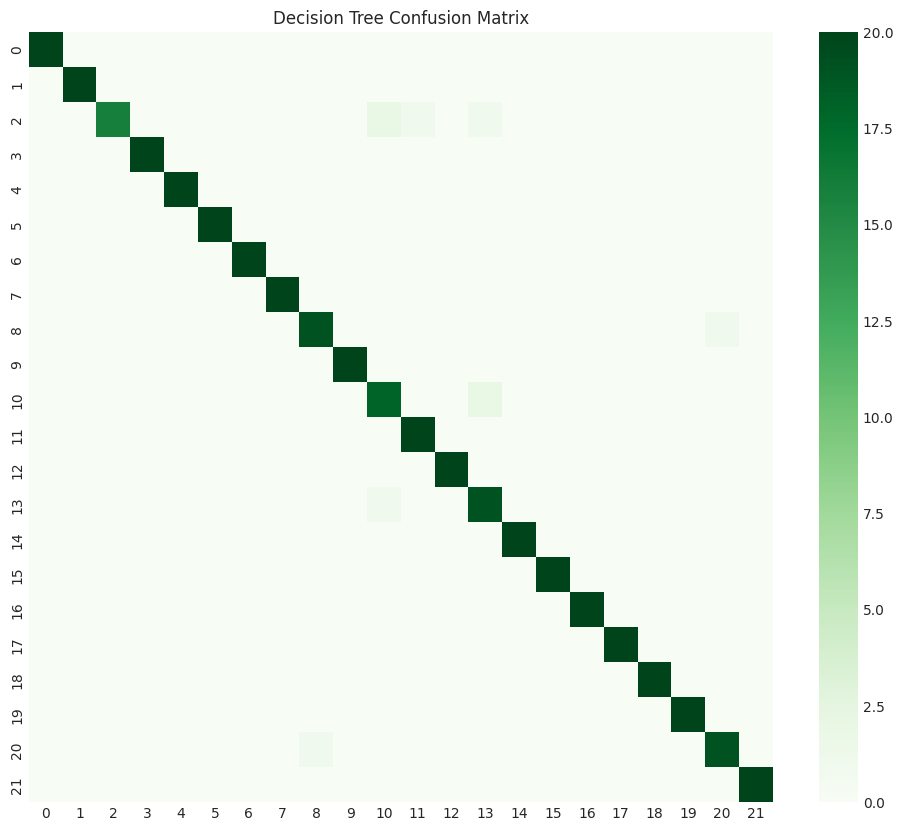

In [113]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm_dt,
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")

plt.show()


In [114]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", accuracy_rf)


Accuracy: 0.9954545454545455


In [115]:

print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00    

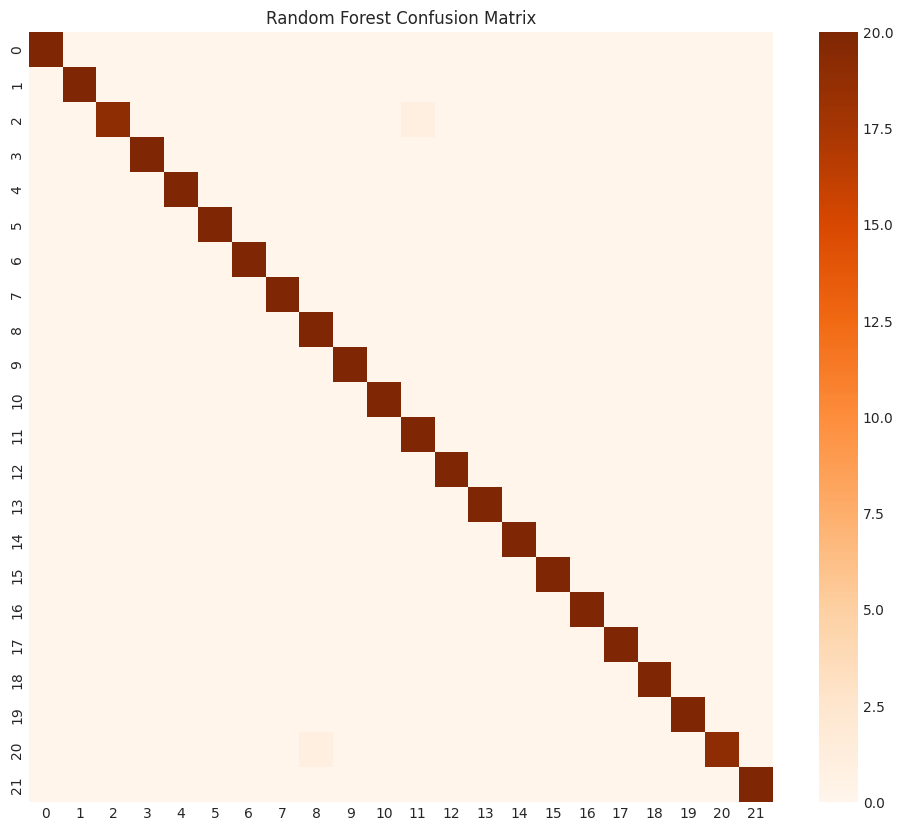

In [116]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm_rf,
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")

plt.show()


In [117]:
comparison = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ]
}
import pandas as pd

comparison_df = pd.DataFrame(comparison)

comparison_df


,Model,Accuracy
0,Logistic Regression,0.972727
1,Decision Tree,0.979545
2,Random Forest,0.995455


In [118]:
from google.colab import files

uploaded = files.upload()



Saving Oman_Smart_Irrigation_Seasons.xlsx to Oman_Smart_Irrigation_Seasons (1).xlsx


In [119]:
import pandas as pd

oman_df = pd.read_excel("Oman_Smart_Irrigation_Seasons.xlsx")

oman_df.head()

,Wilayah,Governorate,Season,Climate_Zone,Temperature_C,Humidity_%,Rainfall_mm,pH,Irrigation_Type
0,مسقط,مسقط,Summer,Coastal,39,65,2,7.1,Falaj/Modern
1,مسقط,مسقط,Winter,Coastal,25,70,20,7.1,Falaj/Modern
2,مطرح,مسقط,Summer,Coastal,39,65,2,7.1,Falaj/Modern
3,مطرح,مسقط,Winter,Coastal,25,70,20,7.1,Falaj/Modern
4,العامرات,مسقط,Summer,Coastal,39,65,2,7.1,Falaj/Modern


In [120]:
def get_wilayah_data(wilayah, season):

    row = oman_df[
        (oman_df["Wilayah"] == wilayah) &
        (oman_df["Season"] == season)
    ]

    return row



In [121]:
get_wilayah_data("نزوى","Summer")


,Wilayah,Governorate,Season,Climate_Zone,Temperature_C,Humidity_%,Rainfall_mm,pH,Irrigation_Type
46,نزوى,الداخلية,Summer,Dry,41,25,2,7.5,Falaj/Modern


In [122]:
def recommend_crop(wilayah, season, N, P, K):

    row = oman_df[
        (oman_df["Wilayah"] == wilayah) &
        (oman_df["Season"] == season)
    ]

    if len(row) == 0:
        return "❌ الولاية غير موجودة"

    temperature = row["Temperature_C"].values[0]
    humidity = row["Humidity_%"].values[0]
    rainfall = row["Rainfall_mm"].values[0]
    ph = row["pH"].values[0]

    #  ML Input
    input_data = pd.DataFrame({
        "N": [N],
        "P": [P],
        "K": [K],
        "temperature": [temperature],
        "humidity": [humidity],
        "ph": [ph],
        "rainfall": [rainfall]
    })

    prediction = rf_model.predict(input_data)

    crop_name = le.inverse_transform(prediction)[0]
    crop_name_ar = crop_ar.get(crop_name, crop_name)

    season_ar = {
        "Summer": "الصيف",
        "Winter": "الشتاء"
    }

    print("\n" + "="*50)
    print("🌍 الولاية:", wilayah)
    print("🌤 الفصل:", season_ar.get(season, season))

    print("🌾 المحصول المقترح:", crop_name_ar)

    print("\n🌦 معلومات الطقس:")
    print("🌡 درجة الحرارة:", temperature)
    print("💧 الرطوبة:", humidity)
    print("🌧 كمية الأمطار:", rainfall)
    print("⚗️ درجة الحموضة:", ph)

In [123]:
crop_ar = {
    "rice": "أرز",
    "maize": "ذرة",
    "chickpea": "حمص",
    "kidneybeans": "فاصوليا حمراء",
    "pigeonpeas": "بازلاء حمام",
    "mothbeans": "فاصوليا العثة",
    "mungbean": "ماش",
    "blackgram": "ماش أسود",
    "lentil": "عدس",
    "pomegranate": "رمان",
    "banana": "موز",
    "mango": "مانجو",
    "grapes": "عنب",
    "watermelon": "بطيخ",
    "muskmelon": "شمام",
    "apple": "تفاح",
    "orange": "برتقال",
    "papaya": "بابايا",
    "coconut": "جوز الهند",
    "cotton": "قطن",
    "jute": "جوت",
    "coffee": "قهوة"
}






In [124]:
recommend_crop(
    wilayah="نزوى",
    season="Summer",
    N=90,
    P=42,
    K=43
)




🌍 الولاية: نزوى
🌤 الفصل: الصيف
🌾 المحصول المقترح: شمام

🌦 معلومات الطقس:
🌡 درجة الحرارة: 41
💧 الرطوبة: 25
🌧 كمية الأمطار: 2
⚗️ درجة الحموضة: 7.5


In [125]:
from ipywidgets import Dropdown, IntSlider, Button, VBox, HTML
from IPython.display import display

wilayah_dropdown = Dropdown(
    options=sorted(oman_df["Wilayah"].unique()),
    description='🌍 الولاية:',
    style={'description_width': 'initial'}
)

season_dropdown = Dropdown(
    options=[("☀️ الصيف", "Summer"), ("❄️ الشتاء", "Winter")],
    description='🌤 الفصل:',
    style={'description_width': 'initial'}
)



n_slider = IntSlider(
    value=90, min=0, max=150,
    description='🌿 N (نيتروجين)',
    style={'description_width': 'initial'}
)

p_slider = IntSlider(
    value=40, min=0, max=150,
    description='🧪 P (فوسفور)',
    style={'description_width': 'initial'}
)

k_slider = IntSlider(
    value=40, min=0, max=150,
    description='🪨 K (بوتاسيوم)',
    style={'description_width': 'initial'}
)


button = Button(
    description='🌾 اقترح محصول',
    button_style='success'
)

def on_button_click(b):
    print("\n" + "="*50)

    recommend_crop(
        wilayah=wilayah_dropdown.value,
        season=season_dropdown.value,
        N=n_slider.value,
        P=p_slider.value,
        K=k_slider.value
    )

button.on_click(on_button_click)

display(VBox([
    wilayah_dropdown,
    season_dropdown,
    n_slider,
    p_slider,
    k_slider,
    button
]))



🌍 الولاية: أدم
🌤 الفصل: الصيف
🌾 المحصول المقترح: شمام
🎯 نسبة الثقة: 33.00%

🏆 أفضل 3 محاصيل:
1. شمام (33.00%)
2. فاصوليا حمراء (17.80%)
3. قهوة (13.08%)

🌦 معلومات الطقس:
🌡 درجة الحرارة: 41
💧 الرطوبة: 25
🌧 كمية الأمطار: 2
⚗️ درجة الحموضة: 7.5

🇴🇲 Omani Smart Agriculture Score: 90/100

🧪 تحليل التربة:
✅ مستويات NPK جيدة ولا تحتاج إلى تعديل كبير


In [126]:
def recommend_crop(wilayah, season, N, P, K):

    row = oman_df[
        (oman_df["Wilayah"] == wilayah) &
        (oman_df["Season"] == season)
    ]

    if len(row) == 0:
        return "❌ الولاية غير موجودة"

    temperature = row["Temperature_C"].values[0]
    humidity = row["Humidity_%"].values[0]
    rainfall = row["Rainfall_mm"].values[0]
    ph = row["pH"].values[0]

    input_data = pd.DataFrame({
        "N": [N],
        "P": [P],
        "K": [K],
        "temperature": [temperature],
        "humidity": [humidity],
        "ph": [ph],
        "rainfall": [rainfall]
    })

    # Oman Smart Agriculture Score
    oman_score = 100

    if N < 50:
        oman_score -= 15

    if P < 40:
        oman_score -= 15

    if K < 40:
        oman_score -= 15

    if rainfall < 50:
        oman_score -= 10

    oman_score = max(oman_score, 0)

    # Prediction
    prediction = rf_model.predict(input_data)

    probabilities = best_rf.predict_proba(input_data)

    confidence = max(probabilities[0]) * 100

    top3_idx = probabilities[0].argsort()[-3:][::-1]

    crop_name = le.inverse_transform(prediction)[0]

    crop_name_ar = crop_ar.get(crop_name, crop_name)

    season_ar = {
        "Summer": "الصيف",
        "Winter": "الشتاء"
    }

    print("\n" + "=" * 60)

    print("🌍 الولاية:", wilayah)

    print("🌤 الفصل:", season_ar.get(season, season))

    print("🌾 المحصول المقترح:", crop_name_ar)

    print(f"🎯 نسبة الثقة: {confidence:.2f}%")

    print("\n🏆 أفضل 3 محاصيل:")

    for i, idx in enumerate(top3_idx):

        crop = le.inverse_transform([idx])[0]

        crop_ar_name = crop_ar.get(crop, crop)

        crop_score = probabilities[0][idx] * 100

        print(
            f"{i+1}. {crop_ar_name} ({crop_score:.2f}%)"
        )

    print("\n🌦 معلومات الطقس:")

    print("🌡 درجة الحرارة:", temperature)

    print("💧 الرطوبة:", humidity)

    print("🌧 كمية الأمطار:", rainfall)

    print("⚗️ درجة الحموضة:", ph)

    print(
        f"\n🇴🇲 Omani Smart Agriculture Score: {oman_score}/100"
    )

    print("\n🧪 تحليل التربة:")

    if N < 50:
        print("• Nitrogen منخفض → يوصى بإضافة Urea")

    if P < 40:
        print("• Phosphorus منخفض → يوصى بإضافة DAP")

    if K < 40:
        print("• Potassium منخفض → يوصى بإضافة Potash")

    if N >= 50 and P >= 40 and K >= 40:
        print("✅ مستويات NPK جيدة ولا تحتاج إلى تعديل كبير")


In [127]:
from ipywidgets import Dropdown, IntSlider, Button, VBox, HTML
from IPython.display import display

# 🌍 Wilayah
wilayah_dropdown = Dropdown(
    options=sorted(oman_df["Wilayah"].unique()),
    description='🌍 الولاية:',
    style={'description_width': 'initial'}
)

# 🌤 Season
season_dropdown = Dropdown(
    options=[("☀️ الصيف", "Summer"), ("❄️ الشتاء", "Winter")],
    description='🌤 الفصل:',
    style={'description_width': 'initial'}
)

# 🌱 NPK Sliders مع وصف

n_slider = IntSlider(
    value=90, min=0, max=150,
    description='🌿 N (نيتروجين)',
    style={'description_width': 'initial'}
)

p_slider = IntSlider(
    value=40, min=0, max=150,
    description='🧪 P (فوسفور)',
    style={'description_width': 'initial'}
)

k_slider = IntSlider(
    value=40, min=0, max=150,
    description='🪨 K (بوتاسيوم)',
    style={'description_width': 'initial'}
)

# 🎯 زر التشغيل
button = Button(
    description='🌾 اقترح محصول',
    button_style='success'
)

# 🔥 تشغيل الدالة
def on_button_click(b):
    print("\n" + "="*50)

    recommend_crop(
        wilayah=wilayah_dropdown.value,
        season=season_dropdown.value,
        N=n_slider.value,
        P=p_slider.value,
        K=k_slider.value
    )

button.on_click(on_button_click)

# 📦 عرض الواجهة
display(VBox([
    wilayah_dropdown,
    season_dropdown,
    n_slider,
    p_slider,
    k_slider,
    button
]))


In [128]:

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nMean Accuracy:")
print(cv_scores.mean())

print("\nStd:")
print(cv_scores.std())


Cross Validation Scores:
[0.99147727 0.99431818 0.99715909 0.99715909 0.98579545]

Mean Accuracy:
0.9931818181818182

Std:
0.004251883394061294


In [129]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)


Best Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}

Best CV Score:
0.9954542195037338


In [130]:

best_rf = grid_search.best_estimator_

print(best_rf)

from sklearn.metrics import accuracy_score

y_pred_best = best_rf.predict(X_test)

best_accuracy = accuracy_score(
    y_test,
    y_pred_best
)

print("Test Accuracy:")
print(best_accuracy)



RandomForestClassifier(max_depth=10, n_estimators=200, n_jobs=-1,
                       random_state=42)
Test Accuracy:
0.9931818181818182


In [131]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50,100,150,200,250,300,400],
    'max_depth': [5,10,15,20,25,None],
    'min_samples_split': [2,5,10,15],
    'min_samples_leaf': [1,2,4,6]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(random_search.best_score_)


Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 25}

Best CV Score:
0.9948863636363636


In [132]:

best_rf_random = random_search.best_estimator_

y_pred_random = best_rf_random.predict(X_test)

print(
    "Test Accuracy:",
    accuracy_score(y_test, y_pred_random)
)


Test Accuracy: 0.9931818181818182


In [133]:
!pip install scikit-optimize

In [134]:
from skopt import BayesSearchCV
from sklearn.ensemble import RandomForestClassifier

bayes_search = BayesSearchCV(
    RandomForestClassifier(random_state=42),
    {
        'n_estimators': (50, 400),
        'max_depth': (5, 30),
        'min_samples_split': (2, 15)
    },
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

bayes_search.fit(X_train, y_train)

print("Best Parameters:")
print(bayes_search.best_params_)

print("\nBest Score:")
print(bayes_search.best_score_)

Best Parameters:
OrderedDict({'max_depth': 17, 'min_samples_split': 2, 'n_estimators': 375})

Best Score:
0.9948863636363636


In [135]:
import pandas as pd

results = {
    "Technique": [
        "Cross Validation",
        "Grid Search",
        "Random Search",
        "Bayesian Optimization"
    ],

    "Accuracy": [
        cv_scores.mean(),
        grid_search.best_score_,
        random_search.best_score_,
        bayes_search.best_score_
    ],

    "Best Hyperparameters": [
        "Default Random Forest",
        str(grid_search.best_params_),
        str(random_search.best_params_),
        str(dict(bayes_search.best_params_))
    ]
}

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

print("=== Model Optimization Comparison ===")
display(results_df)


=== Model Optimization Comparison ===


,Technique,Accuracy,Best Hyperparameters
0,Grid Search,0.995454,"{'max_depth': 10, 'min_samples_split': 2, 'n_e..."
1,Random Search,0.994886,"{'n_estimators': 300, 'min_samples_split': 2, ..."
2,Bayesian Optimization,0.994886,"{'max_depth': 17, 'min_samples_split': 2, 'n_e..."
3,Cross Validation,0.993182,Default Random Forest


In [136]:
best_method = results_df.iloc[0]

print(" Best Optimization Technique")
print("----------------------------------")
print("Technique :", best_method["Technique"])
print("Accuracy  :", round(best_method["Accuracy"], 5))
print("Parameters:", best_method["Best Hyperparameters"])


 Best Optimization Technique
----------------------------------
Technique : Grid Search
Accuracy  : 0.99545
Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


In [137]:
print("="*50)
print("FINAL MODEL")
print("="*50)

print("Algorithm: Random Forest")
print("Optimization Method: Grid Search")

print("\nBest Hyperparameters:")
print("n_estimators =", 200)
print("max_depth =", 10)
print("min_samples_split =", 2)

print("\nFinal Accuracy:", round(grid_search.best_score_,4))


FINAL MODEL
Algorithm: Random Forest
Optimization Method: Grid Search

Best Hyperparameters:
n_estimators = 200
max_depth = 10
min_samples_split = 2

Final Accuracy: 0.9955


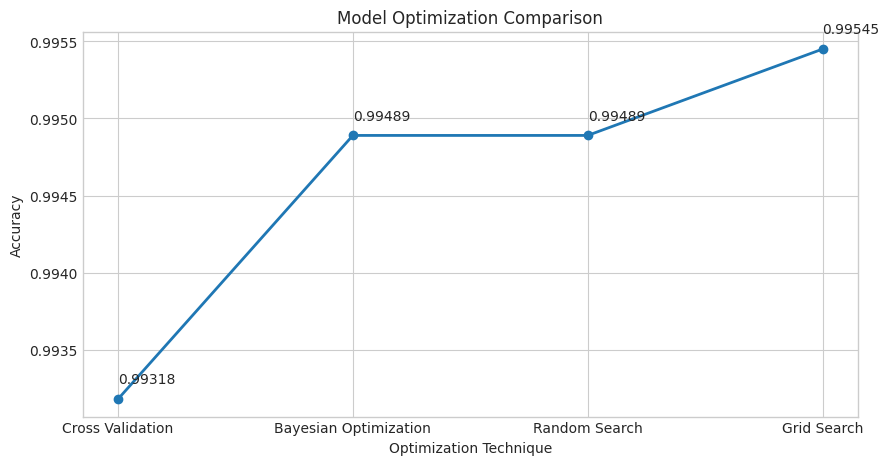

In [138]:
import matplotlib.pyplot as plt

methods = [
    "Cross Validation",
    "Bayesian Optimization",
    "Random Search",
    "Grid Search"
]

accuracy = [
    0.99318,
    0.99489,
    0.99489,
    0.99545
]

plt.figure(figsize=(10,5))
plt.plot(methods, accuracy, marker='o', linewidth=2)

plt.title("Model Optimization Comparison")
plt.xlabel("Optimization Technique")
plt.ylabel("Accuracy")

for i, acc in enumerate(accuracy):
    plt.text(i, acc+0.0001, f"{acc:.5f}")

plt.grid(True)
plt.show()



/tmp/ipykernel_3762/2050762901.py:86: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


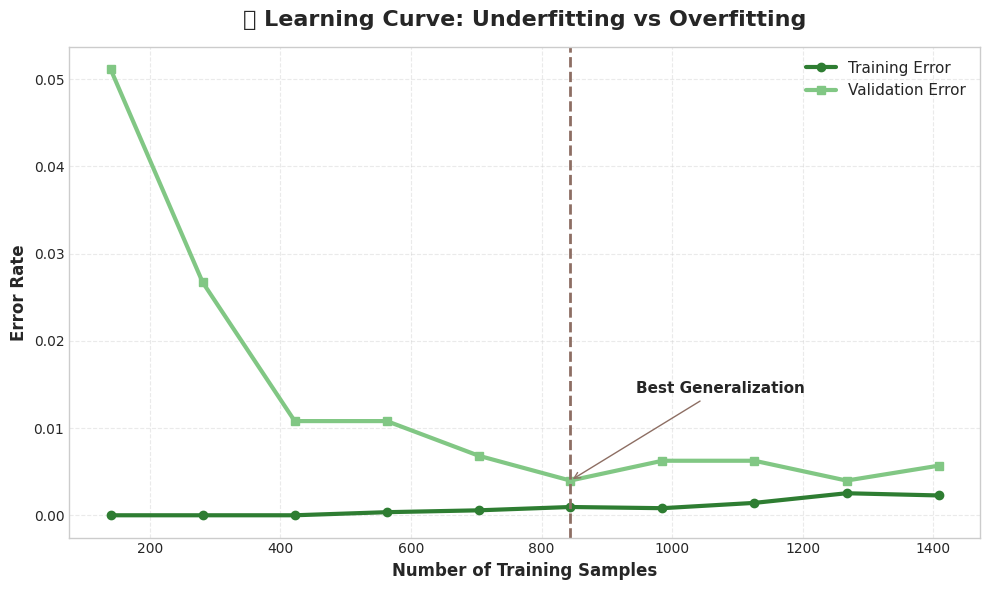

In [139]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_error = 1 - train_scores.mean(axis=1)
test_error = 1 - test_scores.mean(axis=1)

plt.figure(figsize=(10,6))

plt.plot(
    train_sizes,
    train_error,
    marker="o",
    linewidth=3,
    color="#2E7D32",
    label="Training Error"
)

plt.plot(
    train_sizes,
    test_error,
    marker="s",
    linewidth=3,
    color="#81C784",
    label="Validation Error"
)

best_idx = np.argmin(test_error)

plt.axvline(
    train_sizes[best_idx],
    color="#8D6E63",
    linestyle="--",
    linewidth=2
)

plt.annotate(
    "Best Generalization",
    xy=(train_sizes[best_idx], test_error[best_idx]),
    xytext=(train_sizes[best_idx] + 100,
            test_error[best_idx] + 0.01),
    arrowprops=dict(
        arrowstyle="->",
        color="#8D6E63"
    ),
    fontsize=11,
    fontweight="bold"
)

plt.title(
    "🌱 Learning Curve: Underfitting vs Overfitting",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Number of Training Samples",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Error Rate",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.legend(fontsize=11)

plt.tight_layout()
plt.show()



In [140]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'kagglehub', 'path', '_i2', 'files', 'uploaded', '_i3', 'pd', 'df', '_3', '_i4', '_i5', '_5', '_i6', '_6', '_i7', '_7', '_i8', '_8', '_i9', 'plt', 'sns', 'palette', 'ax', 'p', '_i10', 'cmap', '_i11', '_i12', 'LabelEncoder', 'le', '_12', '_i13', 'X', 'y', '_i14', 'train_test_split', 'X_train', 'X_test', 'y_train', 'y_test', '_i15', '_i16', 'StandardScaler', 'scaler', 'X_train_scaled', 'X_test_scaled', '_i17', 'LogisticRegression', 'accuracy_score', 'classification_report', 'lr_model', 'y_pred_lr', 'accuracy_lr', '_i18', '_i19', 'confusion_matrix', 'cm', '_i20', 'DecisionTreeClassifier', 'dt_model', 'y_pred_dt', 'accuracy_dt', '_i21', '_i22', 'cm_dt', '_i23', 'RandomForestClassifier', 'rf_model', 'y_pred_rf', 'accuracy_rf', '_i24', '_i25', 'cm_rf', '_i26', 'comparison', 'com

In [141]:

from sklearn.model_selection import train_test_split

# Train + Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# validation + Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)



Train: (1540, 7)
Validation: (330, 7)
Test: (330, 7)


In [142]:


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Prediction
y_pred = best_rf.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("="*40)
print("MODEL EVALUATION")
print("="*40)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

MODEL EVALUATION
Accuracy  : 0.9970
Precision : 0.9972
Recall    : 0.9970
F1-Score  : 0.9970


In [143]:

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        15
           3       1.00      1.00      1.00        15
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00        15
           6       1.00      1.00      1.00        15
           7       1.00      1.00      1.00        15
           8       0.94      1.00      0.97        15
           9       1.00      1.00      1.00        15
          10       1.00      1.00      1.00        15
          11       1.00      1.00      1.00        15
          12       1.00      1.00      1.00        15
          13       1.00      1.00      1.00        15
          14       1.00      1.00      1.00        15
          15       1.00      1.00      1.00        15
          16       1.00      1.00      1.00        15
          17       1.00    

,Feature,Importance
4,humidity,0.2178
6,rainfall,0.2149
2,K,0.1887
1,P,0.1505
0,N,0.1044
3,temperature,0.0739
5,ph,0.0498


/tmp/ipykernel_3762/162847162.py:67: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


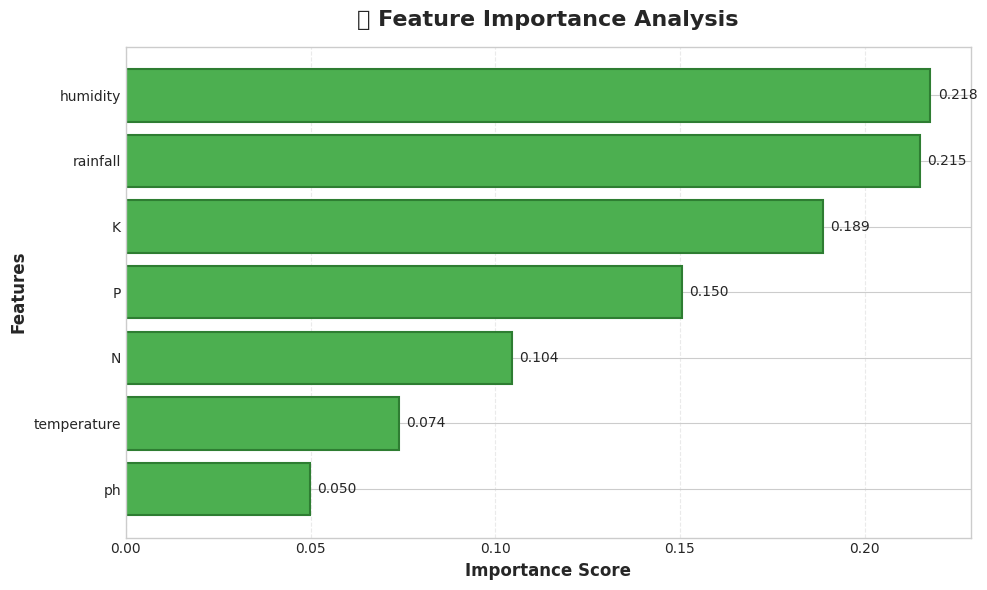

In [144]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(
    importance_df.style
    .background_gradient(cmap="YlGn")
    .format({"Importance": "{:.4f}"})
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    importance_df["Feature"],
    importance_df["Importance"],
    color="#4CAF50",
    edgecolor="#2E7D32",
    linewidth=1.5
)

plt.title(
    "🌾 Feature Importance Analysis",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Importance Score",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Features",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [145]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler_knn = StandardScaler()

X_train_knn_scaled = scaler_knn.fit_transform(X_train_knn)
X_test_knn_scaled = scaler_knn.transform(X_test_knn)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_knn_scaled, y_train_knn)

y_pred_knn = knn.predict(X_test_knn_scaled)

acc_knn = accuracy_score(y_test_knn, y_pred_knn)

print("KNN Accuracy:", acc_knn)

KNN Accuracy: 0.9795454545454545


In [146]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler_svm = StandardScaler()

X_train_svm_scaled = scaler_svm.fit_transform(X_train_svm)
X_test_svm_scaled = scaler_svm.transform(X_test_svm)

svm_model = SVC()

svm_model.fit(X_train_svm_scaled, y_train_svm)

y_pred_svm = svm_model.predict(X_test_svm_scaled)

acc_svm = accuracy_score(y_test_svm, y_pred_svm)

print("SVM Accuracy:", acc_svm)

SVM Accuracy: 0.9840909090909091


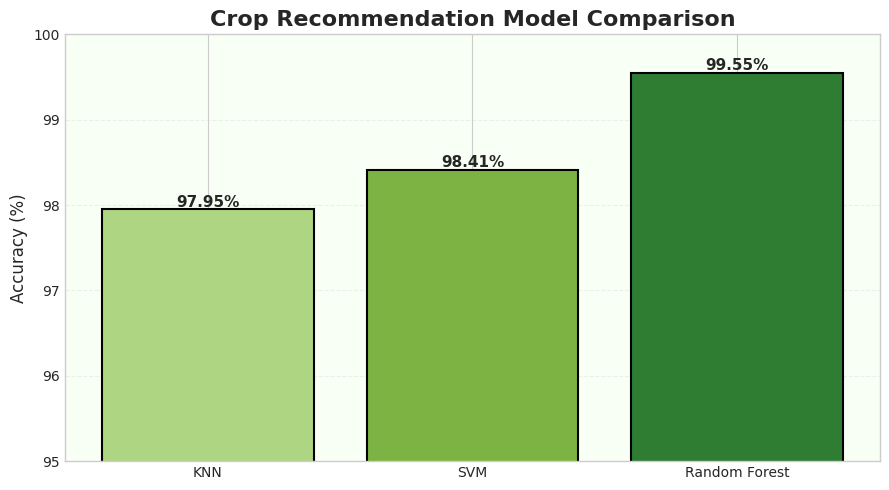

In [147]:
import pandas as pd
import matplotlib.pyplot as plt

# Model comparison data
comparison = pd.DataFrame({
    "Model": ["KNN", "SVM", "Random Forest"],
    "Accuracy": [97.95, 98.41, 99.55]
})

# Create figure
plt.figure(figsize=(9,5))

# Agricultural theme colors
colors = ["#AED581", "#7CB342", "#2E7D32"]

# Bar chart
bars = plt.bar(
    comparison["Model"],
    comparison["Accuracy"],
    color=colors,
    edgecolor="black",
    linewidth=1.5
)

# Title and labels
plt.title(
    "Crop Recommendation Model Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Accuracy (%)", fontsize=12)

# Set y-axis limits
plt.ylim(95, 100)

# Agricultural background
plt.gca().set_facecolor("#F8FFF4")

# Grid lines
plt.grid(axis="y", linestyle="--", alpha=0.3)

# Add accuracy values above bars
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.03,
        f"{y:.2f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

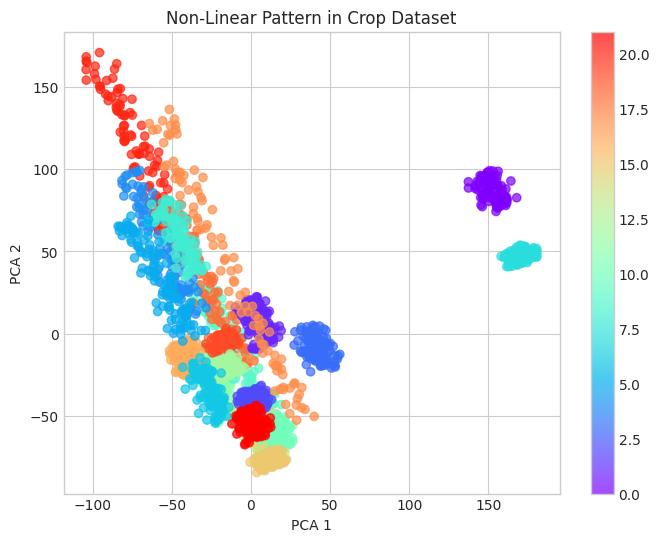

In [148]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

# 🎯 Features
X = df[["N","P","K","temperature","humidity","ph","rainfall"]]

# 🎯 Target
y = df["label"]

# 🔄 Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 📉 PCA reduction
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# 📊 Plot
plt.figure(figsize=(8,6))

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=y_encoded,
    cmap='rainbow',
    alpha=0.7
)

plt.title("Non-Linear Pattern in Crop Dataset")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.colorbar()
plt.show()


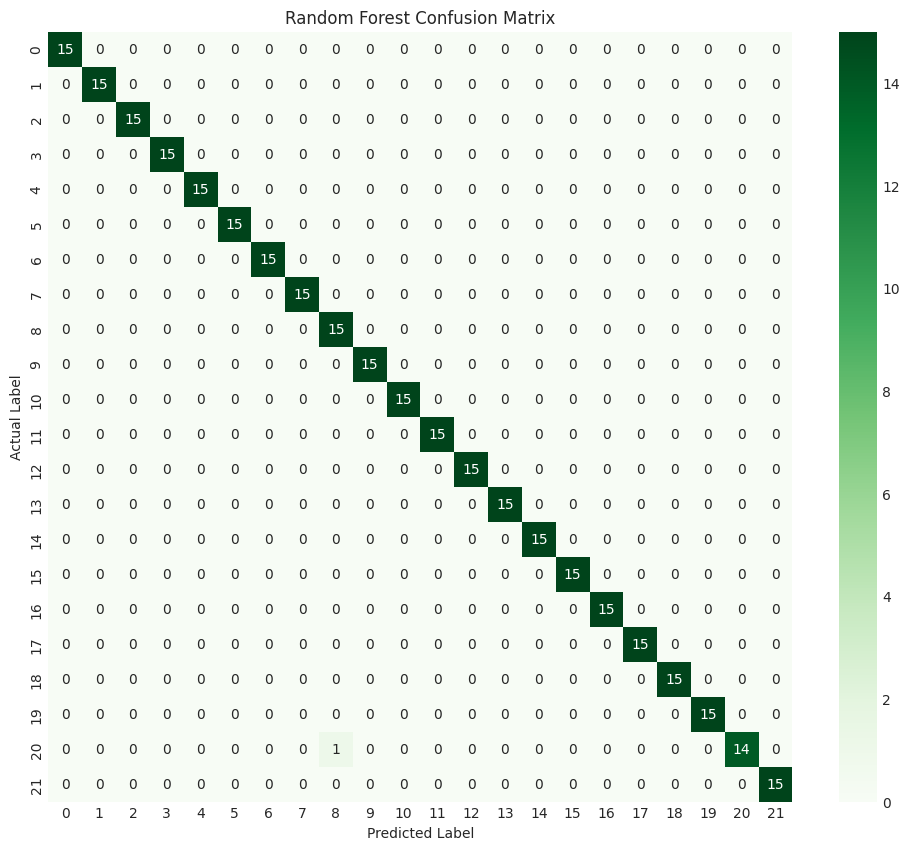

In [149]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prediction
y_pred_rf = best_rf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [150]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Raw Logistic Regression
lr_raw = LogisticRegression(max_iter=5000)

lr_raw.fit(X_train, y_train)

y_pred_raw = lr_raw.predict(X_test)

acc_raw = accuracy_score(y_test, y_pred_raw)

print("Raw Logistic Regression Accuracy:", acc_raw)

Raw Logistic Regression Accuracy: 0.9818181818181818


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [151]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_scaled = LogisticRegression(max_iter=5000)

lr_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = lr_scaled.predict(X_test_scaled)

acc_scaled = accuracy_score(y_test, y_pred_scaled)

print("Scaled Logistic Regression Accuracy:", acc_scaled)

Scaled Logistic Regression Accuracy: 0.9727272727272728


In [152]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C':[0.01,0.1,1,10,100]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_

y_pred_best = best_lr.predict(X_test_scaled)

acc_best = accuracy_score(y_test, y_pred_best)

print("Best Parameters:", grid_lr.best_params_)
print("Tuned Logistic Regression Accuracy:", acc_best)

Best Parameters: {'C': 100}
Tuned Logistic Regression Accuracy: 0.9840909090909091


Final Tuned Logistic Regression Accuracy: 0.9840909090909091

Classification Report
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.87      1.00      0.93        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.95      0.95      0.95        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      0.95      0.95        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        

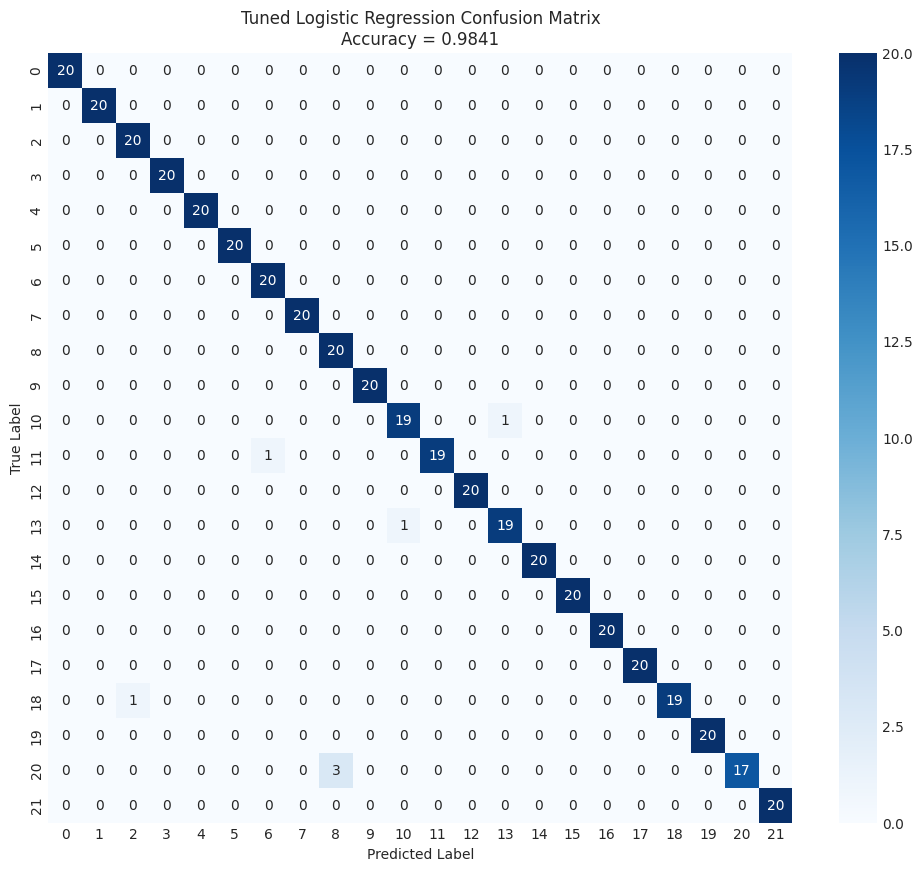

In [153]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions from Tuned Logistic Regression
y_pred_best = best_lr.predict(X_test_scaled)

# Accuracy
from sklearn.metrics import accuracy_score
acc_best = accuracy_score(y_test, y_pred_best)

print("Final Tuned Logistic Regression Accuracy:", acc_best)

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(f"Tuned Logistic Regression Confusion Matrix\nAccuracy = {acc_best:.4f}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [154]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

dt_raw = DecisionTreeClassifier(random_state=42)

dt_raw.fit(X_train, y_train)

y_pred_raw = dt_raw.predict(X_test)

acc_raw = accuracy_score(y_test, y_pred_raw)

print("Baseline Decision Tree Accuracy:", acc_raw)

Baseline Decision Tree Accuracy: 0.9795454545454545


In [155]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

y_pred_best = best_dt.predict(X_test)

acc_best = accuracy_score(y_test, y_pred_best)

print("Best Parameters:", grid_dt.best_params_)
print("Tuned Decision Tree Accuracy:", acc_best)

Best Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5}
Tuned Decision Tree Accuracy: 0.9818181818181818


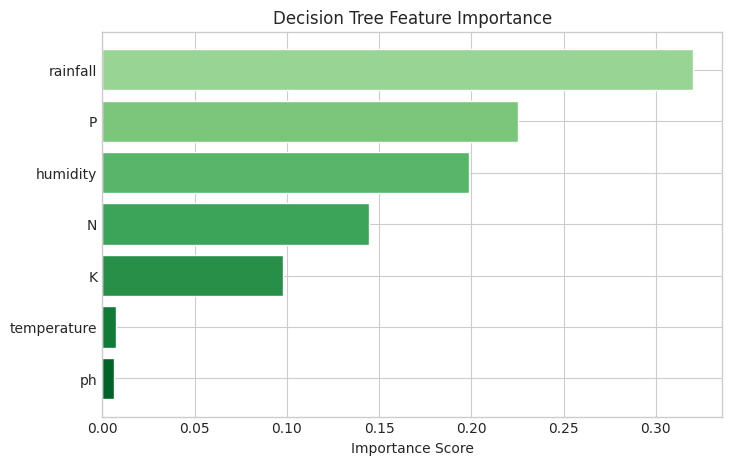

In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))

colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(feature_importance)))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance'],
    color=colors
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()

plt.show()

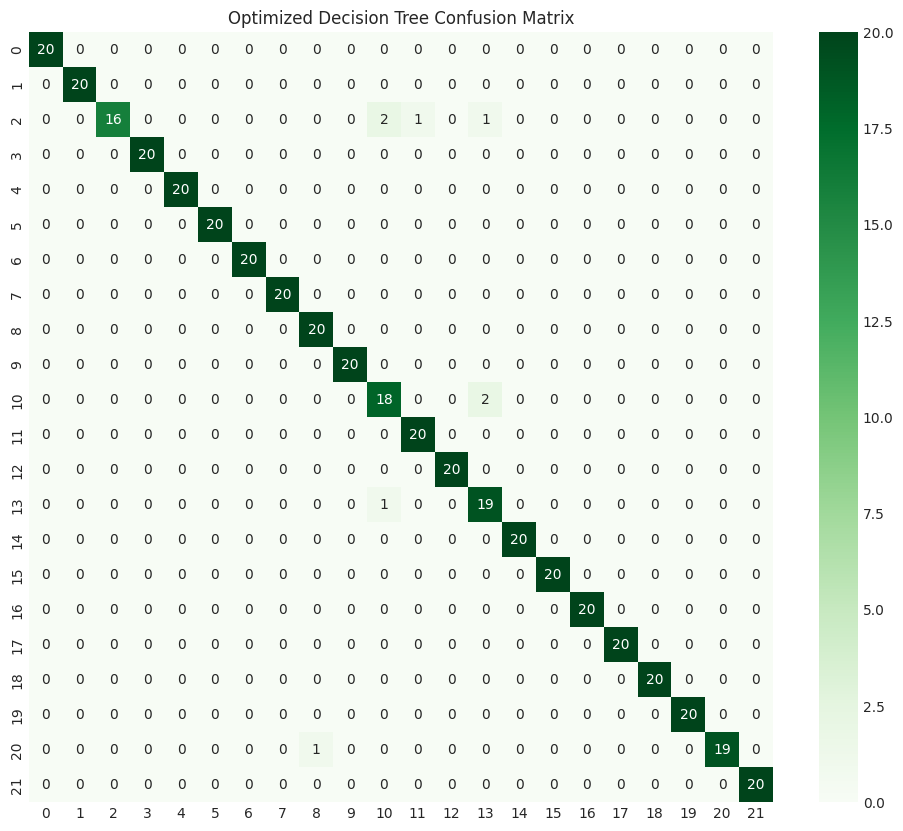

In [157]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Optimized Decision Tree Confusion Matrix")

plt.show()

In [158]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_raw = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_raw.fit(X_train, y_train)

y_pred_raw = rf_raw.predict(X_test)

acc_raw = accuracy_score(y_test, y_pred_raw)

print("Baseline Random Forest Accuracy:", acc_raw)

Baseline Random Forest Accuracy: 0.9954545454545455


In [159]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

y_pred_best = best_rf.predict(X_test)

acc_best = accuracy_score(y_test, y_pred_best)

print("Best Parameters:", grid_rf.best_params_)
print("Optimized Random Forest Accuracy:", acc_best)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Optimized Random Forest Accuracy: 0.9954545454545455


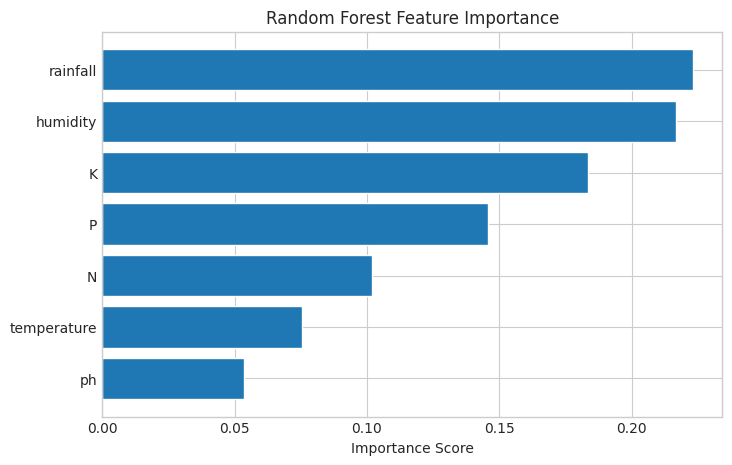

In [160]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")

plt.show()

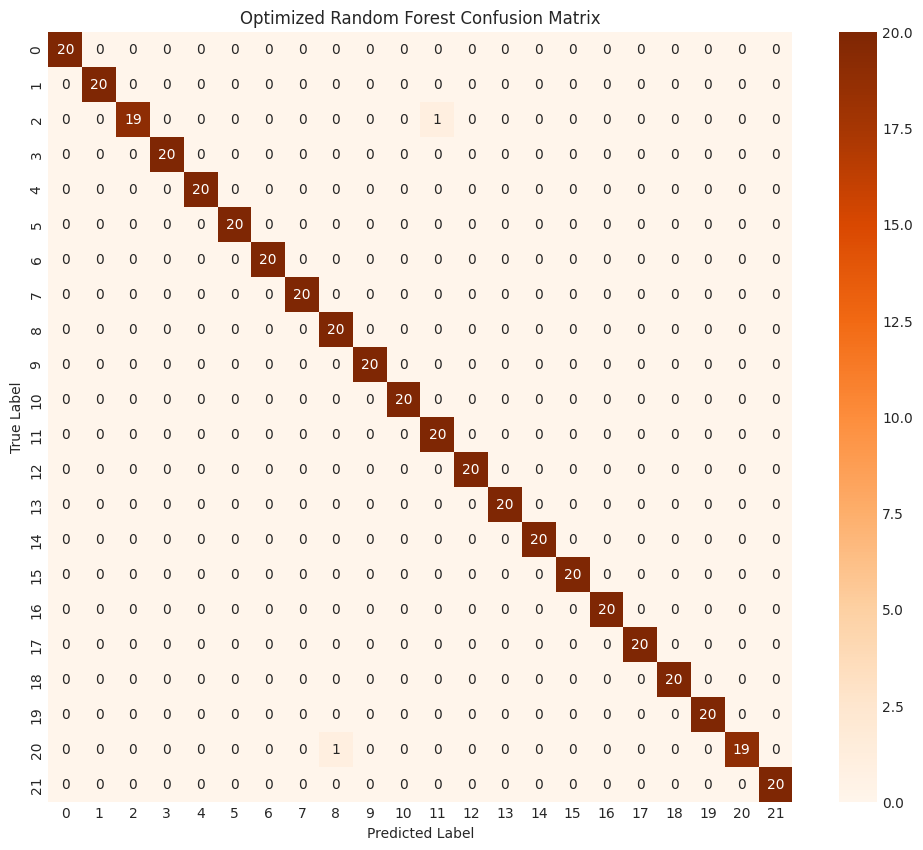

In [161]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Optimized Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [162]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_knn.fit(X_train_knn_scaled, y_train_knn)

best_knn = grid_knn.best_estimator_

y_pred_best = best_knn.predict(X_test_knn_scaled)

acc_best = accuracy_score(y_test_knn, y_pred_best)

print("Best Parameters:", grid_knn.best_params_)
print("Optimized KNN Accuracy:", acc_best)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Optimized KNN Accuracy: 0.9818181818181818


In [163]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

knn_raw = KNeighborsClassifier(n_neighbors=5)

knn_raw.fit(X_train_knn, y_train_knn)

y_pred_raw = knn_raw.predict(X_test_knn)

acc_raw = accuracy_score(y_test_knn, y_pred_raw)

print("Baseline KNN Accuracy:", acc_raw)

Baseline KNN Accuracy: 0.9772727272727273


In [164]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

scaler_knn = StandardScaler()

X_train_knn_scaled = scaler_knn.fit_transform(X_train_knn)
X_test_knn_scaled = scaler_knn.transform(X_test_knn)

knn_scaled = KNeighborsClassifier(n_neighbors=5)

knn_scaled.fit(X_train_knn_scaled, y_train_knn)

y_pred_scaled = knn_scaled.predict(X_test_knn_scaled)

acc_scaled = accuracy_score(y_test_knn, y_pred_scaled)

print("Scaled KNN Accuracy:", acc_scaled)

Scaled KNN Accuracy: 0.9795454545454545


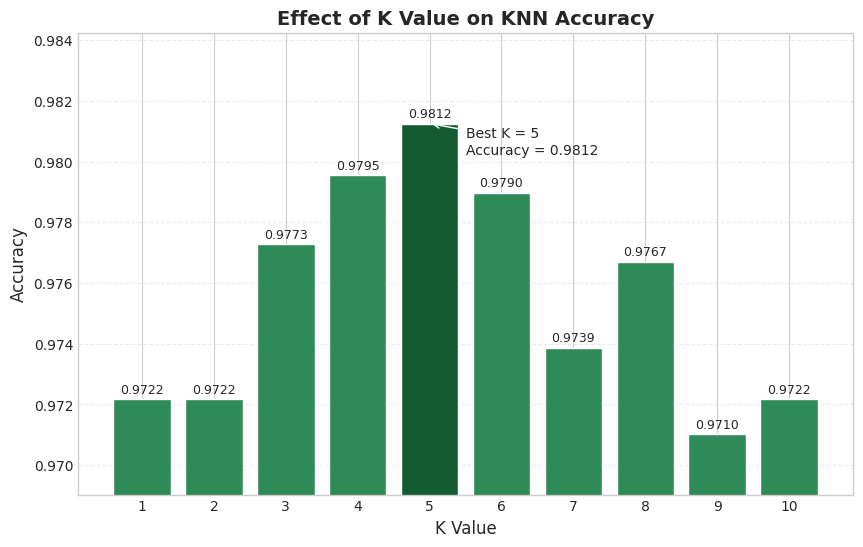

Best K: 5
Best Accuracy: 0.9812


In [165]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

k_values = range(1, 11)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights=grid_knn.best_params_['weights'],
        metric=grid_knn.best_params_['metric']
    )

    scores = cross_val_score(
        knn,
        X_train_knn_scaled,
        y_train_knn,
        cv=5,
        scoring='accuracy'
    )

    accuracies.append(scores.mean())

best_k = list(k_values)[accuracies.index(max(accuracies))]
best_accuracy = max(accuracies)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    list(k_values),
    accuracies,
    color=[
        '#2E8B57' if k != best_k else '#145A32'
        for k in k_values
    ]
)

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        acc + 0.0002,
        f'{acc:.4f}',
        ha='center',
        fontsize=9
    )

plt.title('Effect of K Value on KNN Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

plt.xticks(list(k_values))

plt.ylim(
    min(accuracies) - 0.002,
    max(accuracies) + 0.003
)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.annotate(
    f'Best K = {best_k}\nAccuracy = {best_accuracy:.4f}',
    xy=(best_k, best_accuracy),
    xytext=(best_k + 0.5, best_accuracy - 0.001),
    arrowprops=dict(arrowstyle='->')
)

plt.show()

print("Best K:", best_k)
print("Best Accuracy:", round(best_accuracy, 4))

In [166]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

svm_raw = SVC(random_state=42)

svm_raw.fit(X_train_svm, y_train_svm)

y_pred_raw = svm_raw.predict(X_test_svm)

acc_raw = accuracy_score(y_test_svm, y_pred_raw)

print("Baseline SVM Accuracy:", acc_raw)

Baseline SVM Accuracy: 0.9840909090909091


In [167]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

scaler_svm = StandardScaler()

X_train_scaled = scaler_svm.fit_transform(X_train_svm)
X_test_scaled = scaler_svm.transform(X_test_svm)

svm_scaled = SVC(random_state=42)

svm_scaled.fit(X_train_scaled, y_train_svm)

y_pred_scaled = svm_scaled.predict(X_test_scaled)

acc_scaled = accuracy_score(y_test_svm, y_pred_scaled)

print("Scaled SVM Accuracy:", acc_scaled)

Scaled SVM Accuracy: 0.9840909090909091


In [168]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_svm.fit(X_train_scaled, y_train_svm)

best_svm = grid_svm.best_estimator_

y_pred_best = best_svm.predict(X_test_scaled)

acc_best = accuracy_score(y_test_svm, y_pred_best)

print("Best Parameters:", grid_svm.best_params_)
print("Optimized SVM Accuracy:", acc_best)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Optimized SVM Accuracy: 0.9886363636363636


In [169]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

for C in [0.01, 0.1, 1, 10, 100]:

    model = SVC(
        C=C,
        kernel='rbf',
        gamma='scale',
        random_state=42
    )

    model.fit(X_train_scaled, y_train_svm)

    pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test_svm, pred)

    print(f"C = {C}  ---> Accuracy = {acc:.4f}")

C = 0.01  ---> Accuracy = 0.8545
C = 0.1  ---> Accuracy = 0.9364
C = 1  ---> Accuracy = 0.9841
C = 10  ---> Accuracy = 0.9886
C = 100  ---> Accuracy = 0.9886


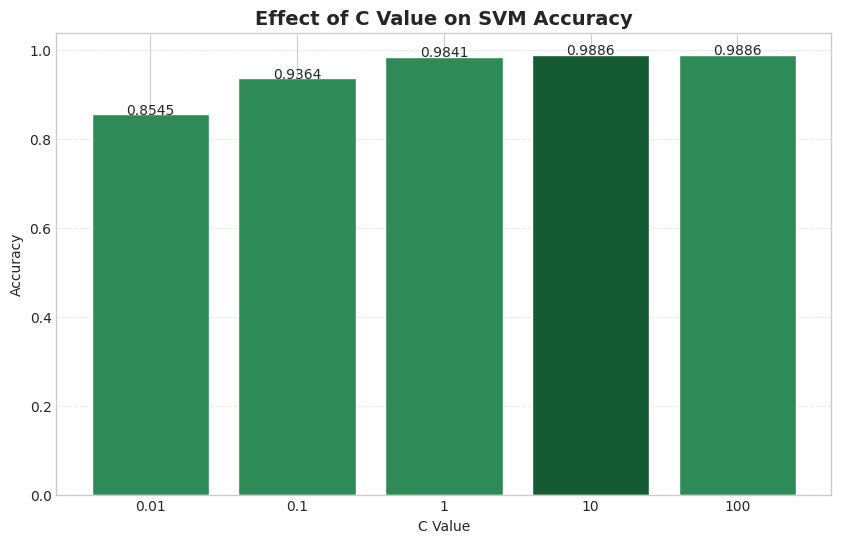

Best C: 10
Best Accuracy: 0.9886


In [170]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

c_values = [0.01, 0.1, 1, 10, 100]
accuracies = []

for C in c_values:

    model = SVC(
        C=C,
        kernel='rbf',
        gamma='scale',
        random_state=42
    )

    model.fit(X_train_scaled, y_train_svm)

    pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test_svm, pred)

    accuracies.append(acc)

best_c = c_values[accuracies.index(max(accuracies))]
best_accuracy = max(accuracies)

plt.figure(figsize=(10,6))

bars = plt.bar(
    range(len(c_values)),
    accuracies,
    color=[
        '#2E8B57' if c != best_c else '#145A32'
        for c in c_values
    ]
)

plt.title('Effect of C Value on SVM Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('C Value')
plt.ylabel('Accuracy')

plt.xticks(range(len(c_values)), c_values)

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        acc + 0.0002,
        f'{acc:.4f}',
        ha='center'
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

print("Best C:", best_c)
print("Best Accuracy:", round(best_accuracy, 4))

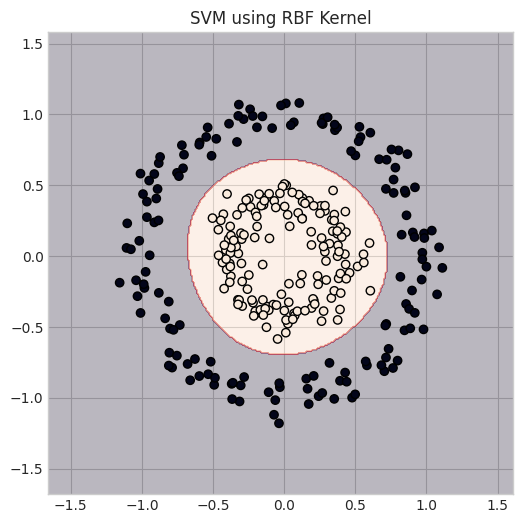

In [171]:
from sklearn.datasets import make_circles
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np

# Create sample data
X, y = make_circles(n_samples=300, factor=0.4,
                    noise=0.08, random_state=42)

svm = SVC(kernel='rbf')
svm.fit(X, y)

# Plot decision boundary
x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')
plt.title("SVM using RBF Kernel")
plt.show()

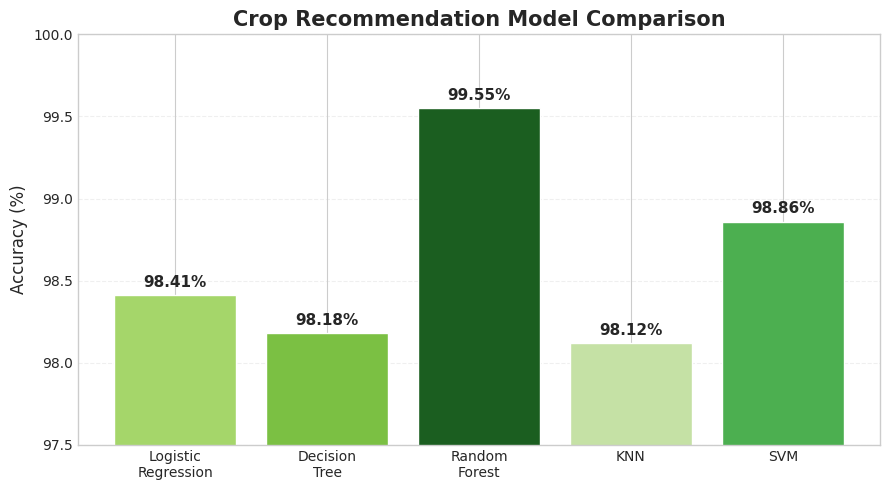

In [172]:
import matplotlib.pyplot as plt

# Models
models = [
    "Logistic\nRegression",
    "Decision\nTree",
    "Random\nForest",
    "KNN",
    "SVM"
]

# Final Accuracy (%)
accuracy = [
    98.41,
    98.18,
    99.55,
    98.12,
    98.86
]

# Colors (Random Forest highlighted)
colors = [
    "#A5D66A",
    "#7BC043",
    "#1B5E20",   # Winner
    "#C5E1A5",
    "#4CAF50"
]

plt.figure(figsize=(9,5))

bars = plt.bar(models, accuracy, color=colors)

plt.title("Crop Recommendation Model Comparison",
          fontsize=15,
          fontweight="bold")

plt.ylabel("Accuracy (%)", fontsize=12)
plt.ylim(97.5, 100)

# Display values above each bar
for bar, value in zip(bars, accuracy):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.05,
        f"{value:.2f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

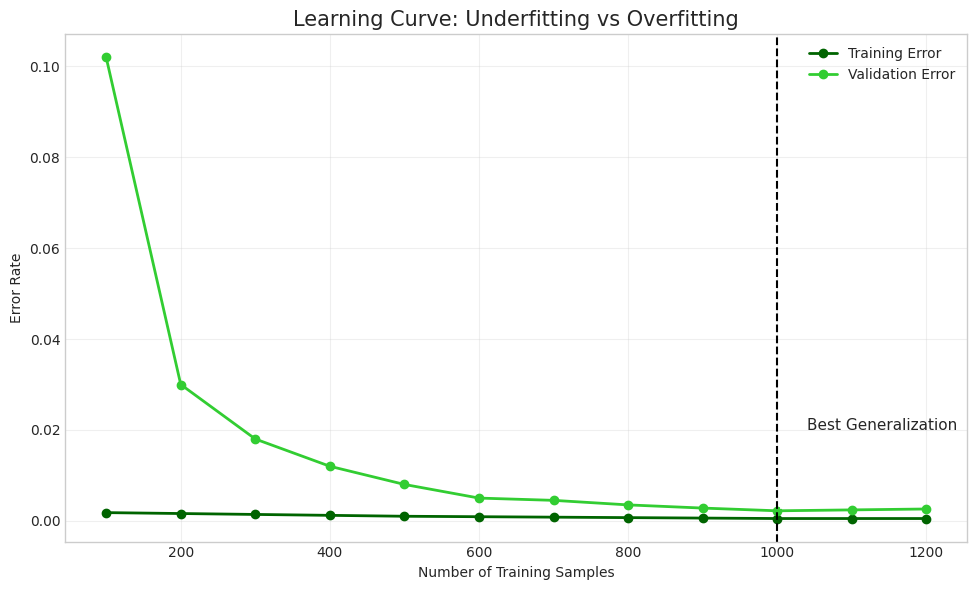

In [173]:
import numpy as np
import matplotlib.pyplot as plt

# Number of training samples
train_sizes = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200]

# Training error
training_error = [
    0.0018, 0.0016, 0.0014, 0.0012,
    0.0010, 0.0009, 0.0008, 0.0007,
    0.0006, 0.0005, 0.0005, 0.0005
]

# Validation error
validation_error = [
    0.102, 0.030, 0.018, 0.012,
    0.008, 0.005, 0.0045, 0.0035,
    0.0028, 0.0022, 0.0024, 0.0026
]

plt.figure(figsize=(10,6))

plt.plot(train_sizes, training_error,
         marker='o',
         linewidth=2,
         color='darkgreen',
         label='Training Error')

plt.plot(train_sizes, validation_error,
         marker='o',
         linewidth=2,
         color='limegreen',
         label='Validation Error')

# Best Generalization
best_index = np.argmin(validation_error)

plt.axvline(
    train_sizes[best_index],
    color='black',
    linestyle='--'
)

plt.annotate(
    'Best Generalization',
    xy=(train_sizes[best_index], validation_error[best_index]),
    xytext=(1040, 0.02),
    arrowprops=dict(arrowstyle='->'),
    fontsize=11
)

plt.title("Learning Curve: Underfitting vs Overfitting", fontsize=15)
plt.xlabel("Number of Training Samples")
plt.ylabel("Error Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

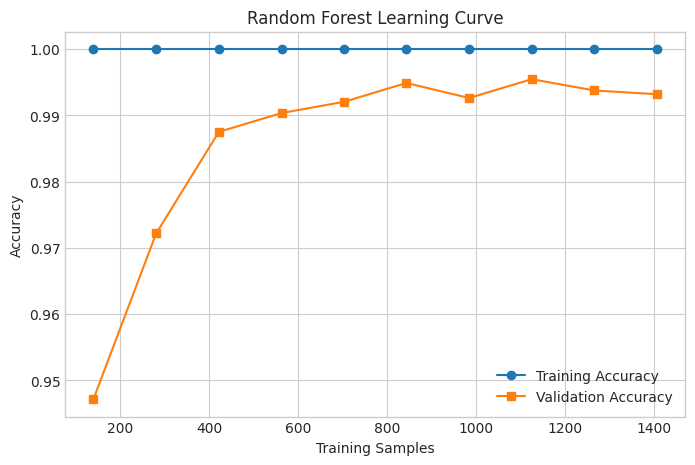

In [174]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    estimator=rf_model,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean,
         marker='o',
         label='Training Accuracy')

plt.plot(train_sizes, val_mean,
         marker='s',
         label='Validation Accuracy')

plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.title("Random Forest Learning Curve")
plt.legend()
plt.grid(True)

plt.show()


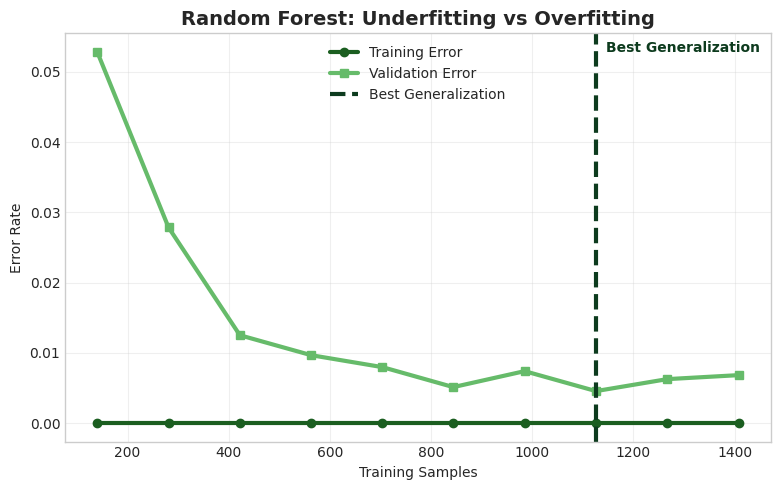

In [175]:
train_error = 1 - train_mean
val_error = 1 - val_mean

best_idx = np.argmin(val_error)
best_size = train_sizes[best_idx]

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_error,
    marker='o',
    linewidth=3,
    color='#1B5E20',
    label='Training Error'
)

plt.plot(
    train_sizes,
    val_error,
    marker='s',
    linewidth=3,
    color='#66BB6A',
    label='Validation Error'
)

plt.axvline(
    x=best_size,
    color='#0D3B1E',
    linestyle='--',
    linewidth=3,
    label='Best Generalization'
)

plt.text(
    best_size + 20,
    max(val_error),
    'Best Generalization',
    color='#0D3B1E',
    fontweight='bold'
)

plt.xlabel("Training Samples")
plt.ylabel("Error Rate")
plt.title(
    "Random Forest: Underfitting vs Overfitting",
    fontsize=14,
    fontweight='bold'
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

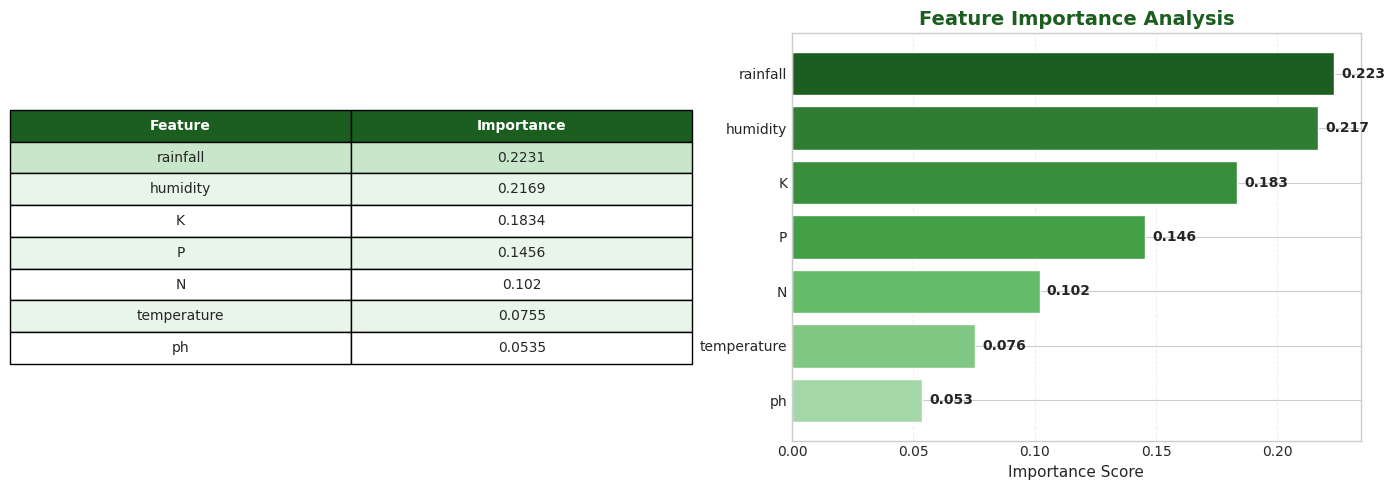

       Feature  Importance
0     rainfall    0.223133
1     humidity    0.216879
2            K    0.183446
3            P    0.145579
4            N    0.101962
5  temperature    0.075522
6           ph    0.053479
       Feature  Importance
0     rainfall    0.223133
1     humidity    0.216879
2            K    0.183446
3            P    0.145579
4            N    0.101962
5  temperature    0.075522
6           ph    0.053479


In [176]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# =========================
# Table
# =========================
ax[0].axis("off")

table = ax[0].table(
    cellText=feature_importance.round(4).values,
    colLabels=feature_importance.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

for (row, col), cell in table.get_celld().items():

    if row == 0:
        cell.set_facecolor("#1B5E20")
        cell.set_text_props(color="white", weight="bold")

    elif row == 1:
        cell.set_facecolor("#C8E6C9")

    elif row % 2 == 0:
        cell.set_facecolor("#E8F5E9")

# =========================
# Bar Chart
# =========================
colors = [
    "#1B5E20",
    "#2E7D32",
    "#388E3C",
    "#43A047",
    "#66BB6A",
    "#81C784",
    "#A5D6A7"
]

bars = ax[1].barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
    color=colors[:len(feature_importance)]
)

ax[1].invert_yaxis()

ax[1].set_title(
    "Feature Importance Analysis",
    fontsize=14,
    fontweight="bold",
    color="#1B5E20"
)

ax[1].set_xlabel(
    "Importance Score",
    fontsize=11
)

ax[1].grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

for bar in bars:
    width = bar.get_width()

    ax[1].text(
        width + 0.003,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

print(feature_importance)
print(feature_importance)

/tmp/ipykernel_3762/1707081491.py:90: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


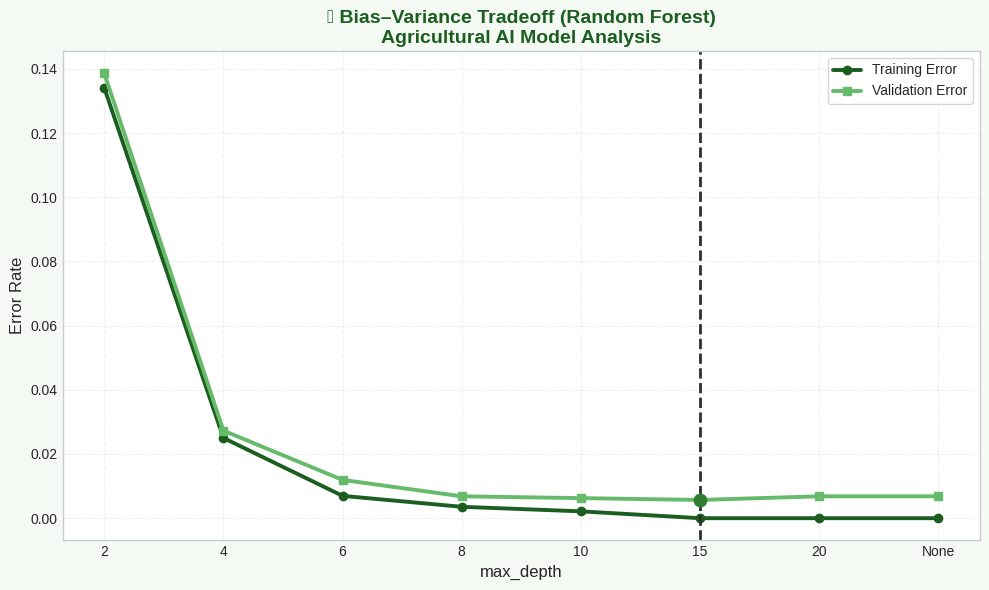

In [177]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve
from sklearn.ensemble import RandomForestClassifier

param_range = [2, 4, 6, 8, 10, 15, 20, None]

train_scores, test_scores = validation_curve(
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    X_train,
    y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_error = 1 - np.mean(train_scores, axis=1)
validation_error = 1 - np.mean(test_scores, axis=1)

# 🌿 Style
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(10,6), facecolor="#f4f9f4")

# Colors
train_color = "#1b5e20"   # deep agricultural green
val_color = "#66bb6a"     # light green

# Plot lines
plt.plot(
    range(len(param_range)),
    train_error,
    marker='o',
    linewidth=2.8,
    color=train_color,
    label='Training Error'
)

plt.plot(
    range(len(param_range)),
    validation_error,
    marker='s',
    linewidth=2.8,
    color=val_color,
    label='Validation Error'
)

# X labels
plt.xticks(
    range(len(param_range)),
    ['2','4','6','8','10','15','20','None']
)

# Highlight best point
best_idx = np.argmin(validation_error)

plt.axvline(
    best_idx,
    color="#2e2e2e",
    linestyle="--",
    linewidth=2
)

plt.scatter(
    best_idx,
    validation_error[best_idx],
    color="#2e7d32",
    s=80,
    zorder=5
)

# Labels
plt.xlabel("max_depth", fontsize=12)
plt.ylabel("Error Rate", fontsize=12)

plt.title(
    "🌱 Bias–Variance Tradeoff (Random Forest)\nAgricultural AI Model Analysis",
    fontsize=14,
    fontweight='bold',
    color="#1b5e20"
)

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(frameon=True, facecolor="white")

plt.tight_layout()
plt.show()

In [178]:
from sklearn.metrics import accuracy_score

# Training Accuracy
y_train_pred = best_rf.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Testing Accuracy
y_test_pred = best_rf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy : {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Testing Accuracy  : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")



Training Accuracy : 0.9966 (99.66%)
Testing Accuracy  : 0.9955 (99.55%)


In [179]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_pred = best_rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9954545454545455
Precision: 0.9956709956709956
Recall   : 0.9954545454545455
F1 Score : 0.9954517027687759

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00 

/tmp/ipykernel_3762/3349021120.py:29: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


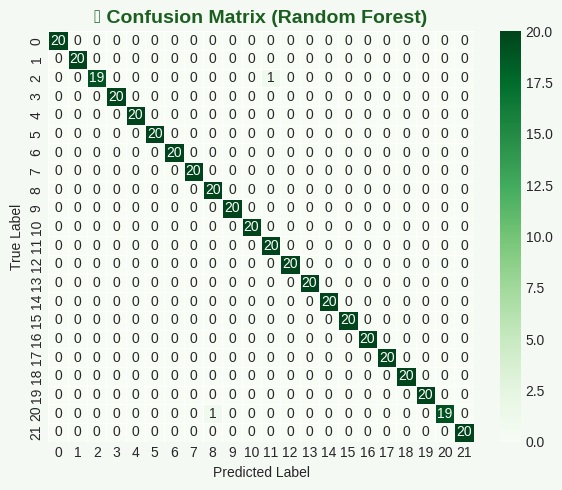

In [180]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ============================
# Confusion Matrix
# ============================
cm = confusion_matrix(y_test, y_pred)

# ============================
# Plot Style (Agricultural Theme)
# ============================
plt.figure(figsize=(6,5), facecolor="#f4f9f4")

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    linewidths=0.5,
    linecolor="white",
    cbar=True
)

plt.title("🌱 Confusion Matrix (Random Forest)", fontsize=14, fontweight='bold', color="#1b5e20")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [195]:
print(predictions.dtype)
print(np.unique(predictions))

NameError: name 'predictions' is not defined

In [184]:
print(y_train.iloc[0])
print(best_rf.predict(X_test)[0])

orange
orange


In [186]:
from sklearn.preprocessing import LabelEncoder

le_temp = LabelEncoder()

# نحول أسماء المحاصيل إلى أرقام مؤقتاً فقط
le_temp.fit(y_train)

predictions_num = np.array([
    le_temp.transform(pred)
    for pred in predictions
])

y_test_num = le_temp.transform(y_test)

NameError: name 'predictions' is not defined

In [187]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import zero_one_loss
import numpy as np
import matplotlib.pyplot as plt

le_temp = LabelEncoder()

le_temp.fit(y_train)

predictions_num = np.array([
    le_temp.transform(pred)
    for pred in predictions
])

y_test_num = le_temp.transform(y_test)

majority_vote = []

for i in range(len(X_test)):
    values, counts = np.unique(predictions[:, i], return_counts=True)
    majority_vote.append(values[np.argmax(counts)])

majority_vote = np.array(majority_vote)

majority_vote_num = le_temp.transform(majority_vote)

bias = zero_one_loss(y_test_num, majority_vote_num)

variance = np.mean(np.var(predictions_num, axis=0))

total_error = bias + variance

plt.figure(figsize=(7,5))

colors = plt.cm.Greens(np.linspace(0.45, 0.9, 3))

bars = plt.bar(
    ["Bias²", "Variance", "Total Error"],
    [bias, variance, total_error],
    color=colors
)

plt.ylabel("Error")
plt.title("Bias-Variance Analysis (Random Forest)")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.002,
        f"{h:.4f}",
        ha="center",
        fontsize=11
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

NameError: name 'predictions' is not defined

In [188]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Prediction
y_pred = best_rf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# أسماء الفئات
labels = best_rf.classes_

cm_df = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

print(cm_df)

             apple  banana  blackgram  chickpea  coconut  coffee  cotton  \
apple           20       0          0         0        0       0       0   
banana           0      20          0         0        0       0       0   
blackgram        0       0         19         0        0       0       0   
chickpea         0       0          0        20        0       0       0   
coconut          0       0          0         0       20       0       0   
coffee           0       0          0         0        0      20       0   
cotton           0       0          0         0        0       0      20   
grapes           0       0          0         0        0       0       0   
jute             0       0          0         0        0       0       0   
kidneybeans      0       0          0         0        0       0       0   
lentil           0       0          0         0        0       0       0   
maize            0       0          0         0        0       0       0   
mango       

In [189]:
import numpy as np

precision = np.diag(cm) / cm.sum(axis=0)
recall    = np.diag(cm) / cm.sum(axis=1)

results = pd.DataFrame({
    "Class": labels,
    "Precision": precision,
    "Recall": recall
})

print(results)


          Class  Precision  Recall
0         apple   1.000000    1.00
1        banana   1.000000    1.00
2     blackgram   1.000000    0.95
3      chickpea   1.000000    1.00
4       coconut   1.000000    1.00
5        coffee   1.000000    1.00
6        cotton   1.000000    1.00
7        grapes   1.000000    1.00
8          jute   0.952381    1.00
9   kidneybeans   1.000000    1.00
10       lentil   1.000000    1.00
11        maize   0.952381    1.00
12        mango   1.000000    1.00
13    mothbeans   1.000000    1.00
14     mungbean   1.000000    1.00
15    muskmelon   1.000000    1.00
16       orange   1.000000    1.00
17       papaya   1.000000    1.00
18   pigeonpeas   1.000000    1.00
19  pomegranate   1.000000    1.00
20         rice   1.000000    0.95
21   watermelon   1.000000    1.00


In [190]:
print("Confusion Matrix\n")
display(cm_df)

print("\nPrecision per Class")
for c,p in zip(labels,precision):
    print(f"{c:15s}: {p:.3f}")

print("\nRecall per Class")
for c,r in zip(labels,recall):
    print(f"{c:15s}: {r:.3f}")


Confusion Matrix



,apple,banana,blackgram,chickpea,coconut,coffee,cotton,grapes,jute,kidneybeans,...,mango,mothbeans,mungbean,muskmelon,orange,papaya,pigeonpeas,pomegranate,rice,watermelon
apple,20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
banana,0,20,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
blackgram,0,0,19,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
chickpea,0,0,0,20,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
coconut,0,0,0,0,20,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
coffee,0,0,0,0,0,20,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
cotton,0,0,0,0,0,0,20,0,0,0,...,0,0,0,0,0,0,0,0,0,0
grapes,0,0,0,0,0,0,0,20,0,0,...,0,0,0,0,0,0,0,0,0,0
jute,0,0,0,0,0,0,0,0,20,0,...,0,0,0,0,0,0,0,0,0,0
kidneybeans,0,0,0,0,0,0,0,0,0,20,...,0,0,0,0,0,0,0,0,0,0



Precision per Class
apple          : 1.000
banana         : 1.000
blackgram      : 1.000
chickpea       : 1.000
coconut        : 1.000
coffee         : 1.000
cotton         : 1.000
grapes         : 1.000
jute           : 0.952
kidneybeans    : 1.000
lentil         : 1.000
maize          : 0.952
mango          : 1.000
mothbeans      : 1.000
mungbean       : 1.000
muskmelon      : 1.000
orange         : 1.000
papaya         : 1.000
pigeonpeas     : 1.000
pomegranate    : 1.000
rice           : 1.000
watermelon     : 1.000

Recall per Class
apple          : 1.000
banana         : 1.000
blackgram      : 0.950
chickpea       : 1.000
coconut        : 1.000
coffee         : 1.000
cotton         : 1.000
grapes         : 1.000
jute           : 1.000
kidneybeans    : 1.000
lentil         : 1.000
maize          : 1.000
mango          : 1.000
mothbeans      : 1.000
mungbean       : 1.000
muskmelon      : 1.000
orange         : 1.000
papaya         : 1.000
pigeonpeas     : 1.000
pomegranate    : 1

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

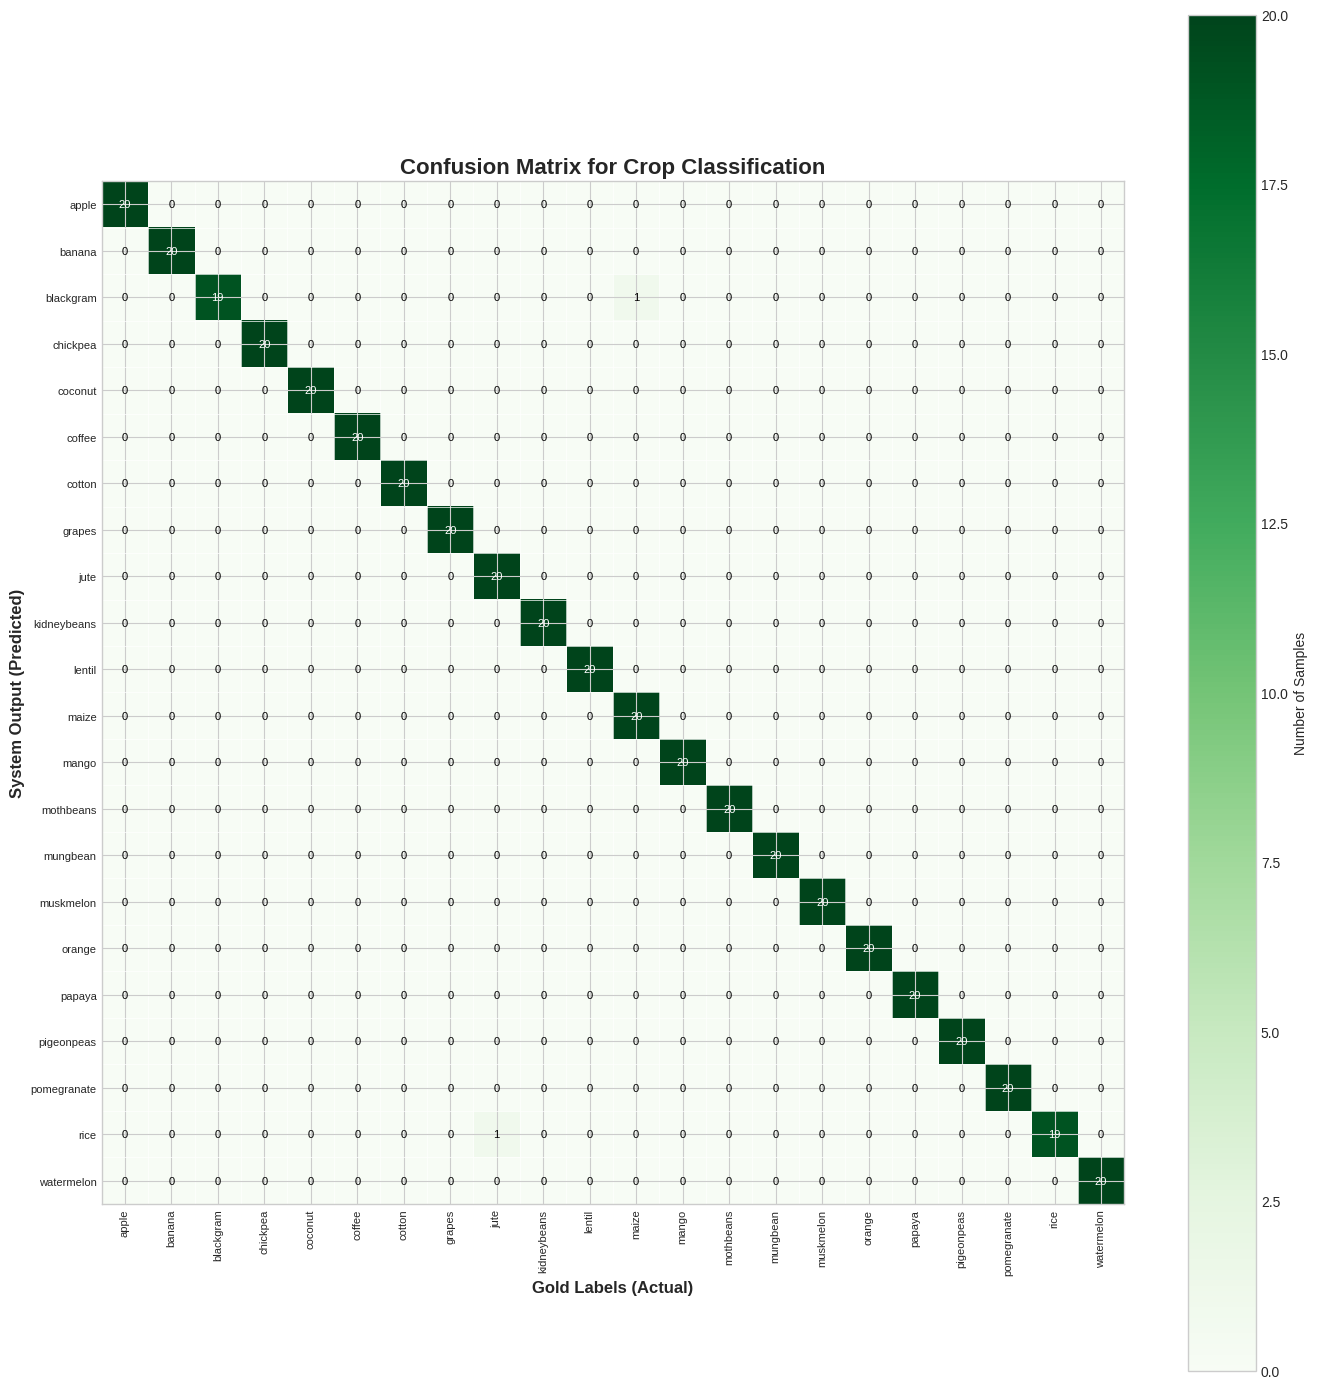

In [191]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

y_pred = best_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

classes = best_rf.classes_

fig, ax = plt.subplots(figsize=(14, 14))

im = ax.imshow(cm, cmap="Greens")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            fontsize=8,
            color="white" if value > cm.max()/2 else "black"
        )

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))

ax.set_xticklabels(classes, rotation=90, fontsize=8)
ax.set_yticklabels(classes, fontsize=8)

ax.set_xlabel("Gold Labels (Actual)", fontsize=12, fontweight="bold")
ax.set_ylabel("System Output (Predicted)", fontsize=12, fontweight="bold")

ax.set_title(
    "Confusion Matrix for Crop Classification",
    fontsize=16,
    fontweight="bold"
)

ax.set_xticks(np.arange(-0.5, len(classes), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(classes), 1), minor=True)

ax.grid(which="minor", color="white", linestyle="-", linewidth=0.5)

ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im)
cbar.set_label("Number of Samples")

fig.tight_layout()

fig.savefig(
    "confusion_matrix_green.png",
    dpi=300,
    bbox_inches="tight"
)

files.download("confusion_matrix_green.png")

plt.show()

In [192]:
from sklearn.linear_model import LogisticRegression

best_lr = LogisticRegression(
    C=100,
    max_iter=5000,
    random_state=42
)

best_lr.fit(X_train_scaled, y_train)

LogisticRegression(C=100, max_iter=5000, random_state=42)

In [ ]:
print("Number of Iterations:", best_lr.n_iter_)

In [ ]:
from sklearn.metrics import log_loss

y_prob = best_lr.predict_proba(X_test_scaled)

loss = log_loss(y_test, y_prob)

print("Log Loss:", loss)

In [ ]:
import pandas as pd

probabilities = pd.DataFrame(
    best_lr.predict_proba(X_test_scaled),
    columns=best_lr.classes_
)

probabilities.head()

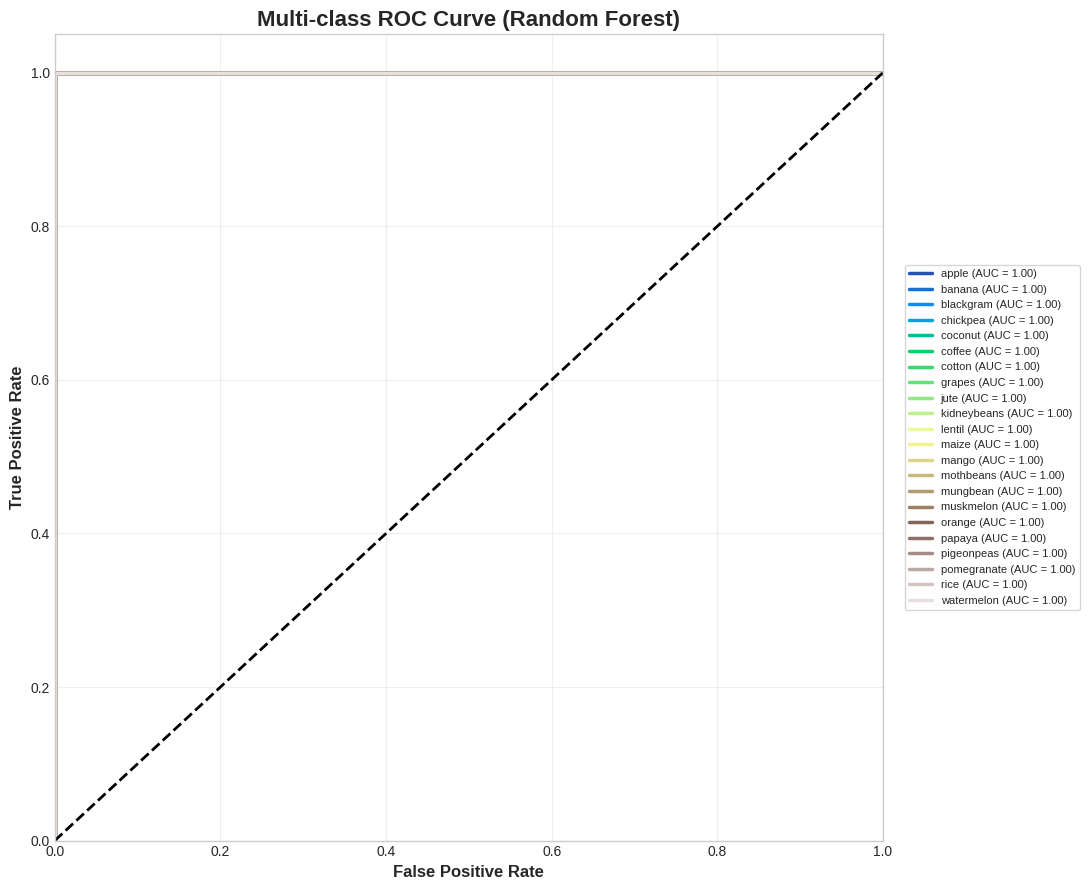

In [194]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

y_score = best_rf.predict_proba(X_test)

colors = plt.cm.terrain(np.linspace(0.05, 0.95, len(lb.classes_)))

plt.figure(figsize=(11,9))

for i, color in enumerate(colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        color=color,
        lw=2.5,
        label=f"{lb.classes_[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot([0,1], [0,1], '--', color='black', lw=2)

plt.xlim([0,1])
plt.ylim([0,1.05])

plt.xlabel("False Positive Rate", fontsize=12, fontweight="bold")
plt.ylabel("True Positive Rate", fontsize=12, fontweight="bold")
plt.title("Multi-class ROC Curve (Random Forest)", fontsize=16, fontweight="bold")

plt.grid(alpha=0.3)
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8,
    frameon=True
)

plt.tight_layout()
plt.show()


In [193]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_auc_score

lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

y_score = best_rf.predict_proba(X_test)

auc_macro = roc_auc_score(
    y_test_bin,
    y_score,
    multi_class="ovr",
    average="macro"
)

auc_weighted = roc_auc_score(
    y_test_bin,
    y_score,
    multi_class="ovr",
    average="weighted"
)

print("Macro ROC AUC :", auc_macro)
print("Weighted ROC AUC :", auc_weighted)

Macro ROC AUC : 1.0
Weighted ROC AUC : 1.0
